In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import tangos as db


In [3]:
db.init_db('data.db')

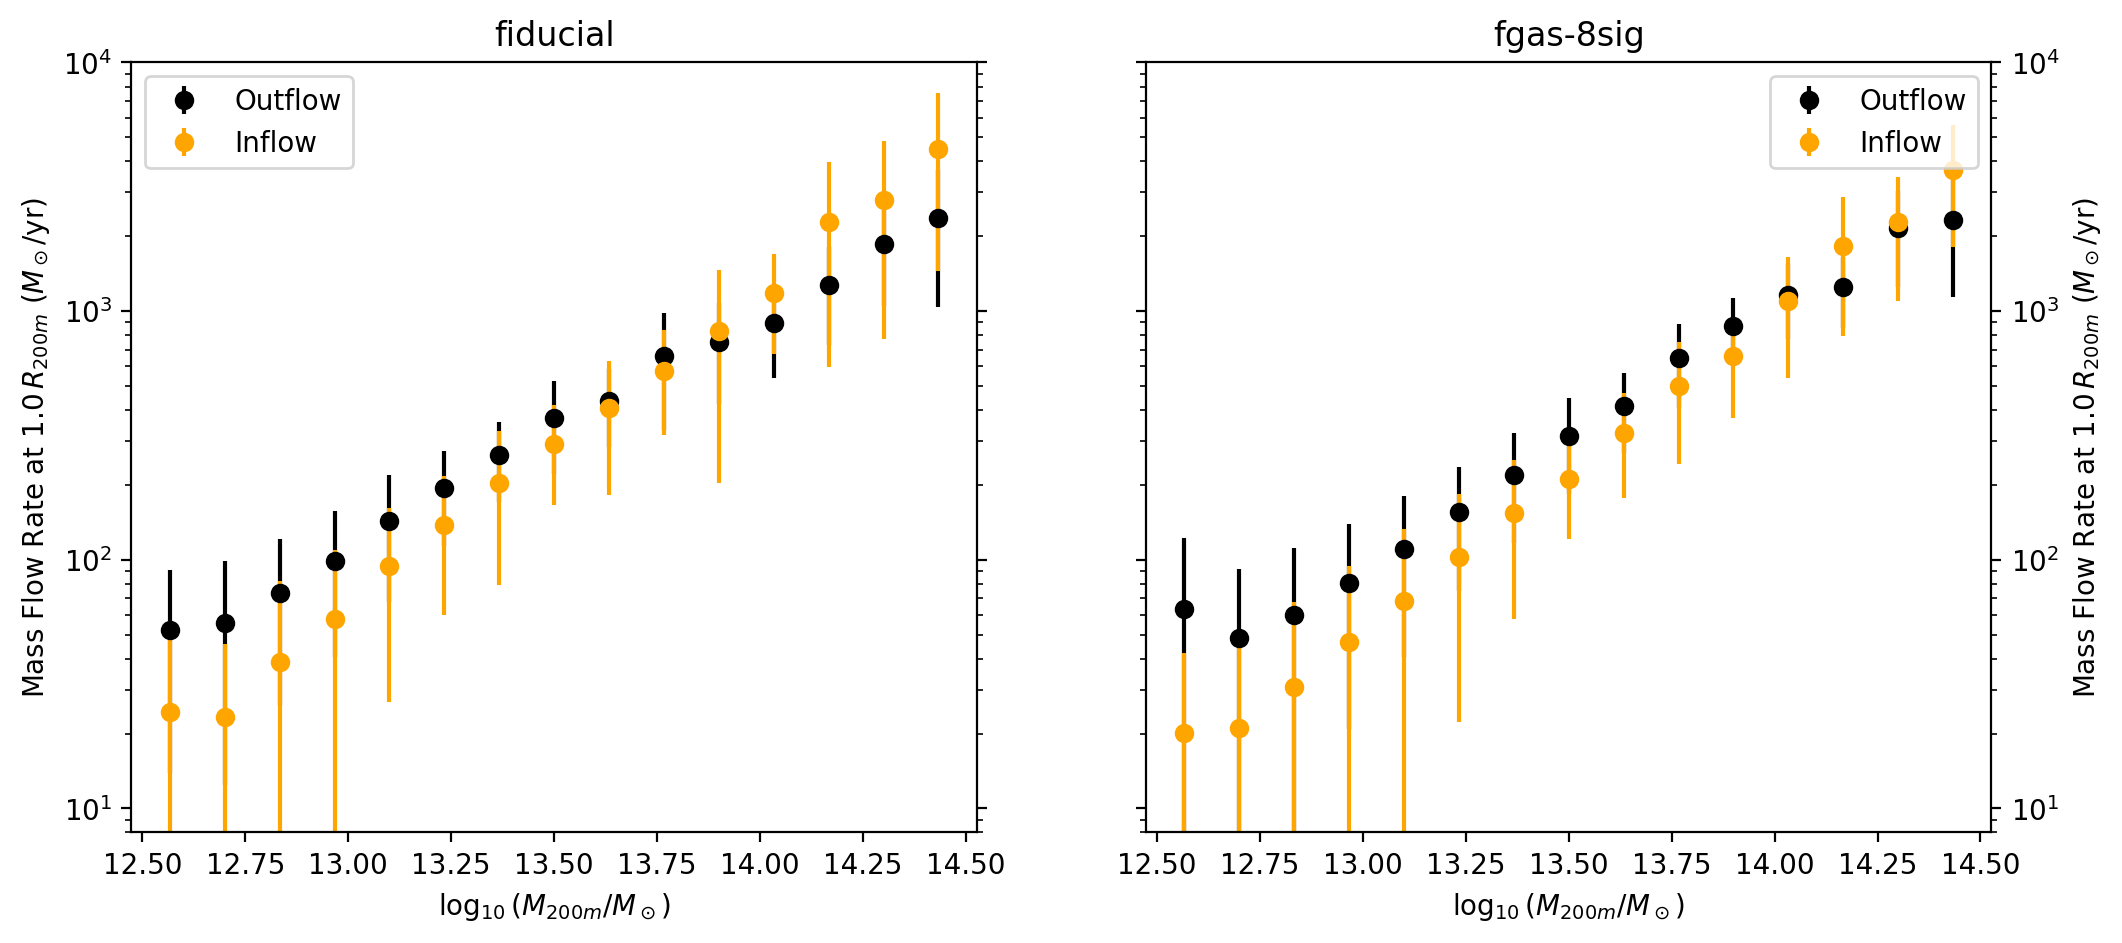

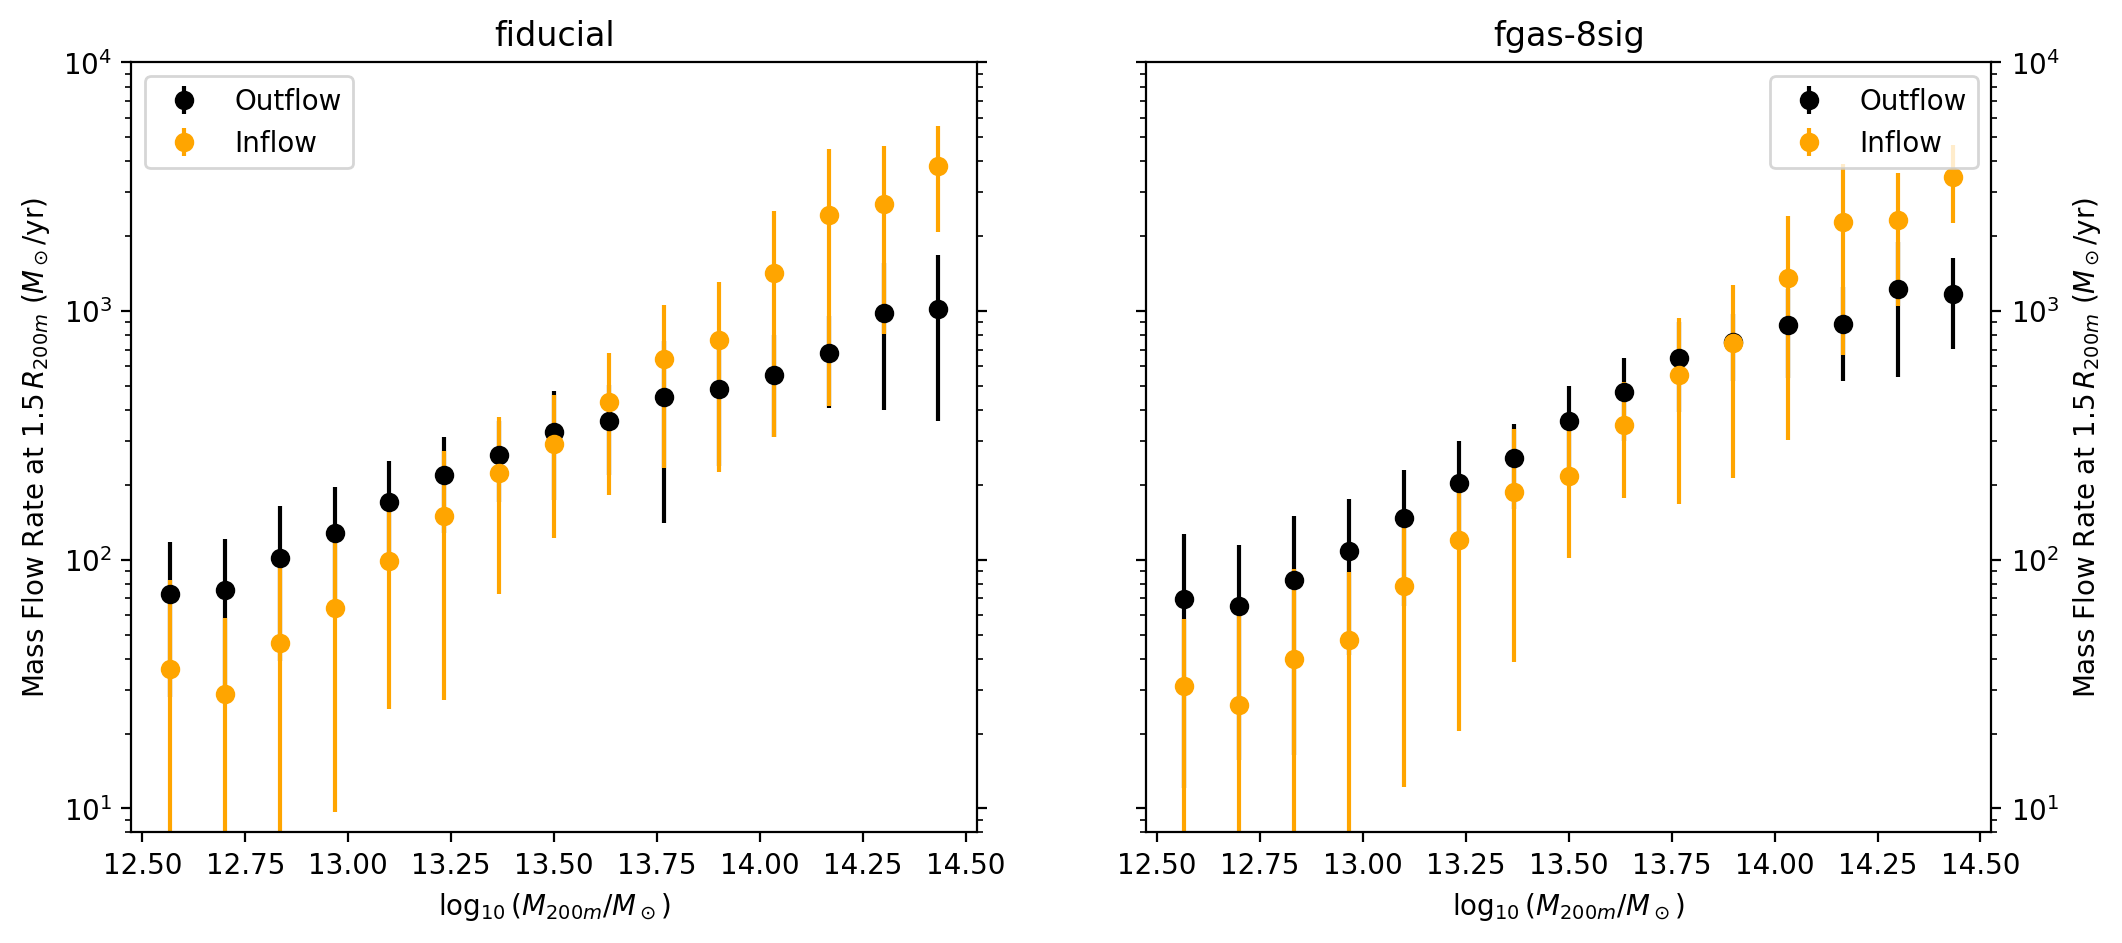

In [4]:

def outflow_by_mass(ts_name, radius=1.0):
    log_rad = np.log10(radius)
    fa.make_binned_by_mass_plot(f'at({log_rad}, gas_mdot_outflow_r200m_relative)', 
                                plot_kwargs={'color': 'black'}, ts_name=ts_name)
    fa.make_binned_by_mass_plot(f'0.0-at({log_rad}, gas_mdot_inflow_r200m_relative)', 
                                plot_kwargs={'color': 'orange'}, ts_name=ts_name)
    p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
    p.ylabel(rf"Mass Flow Rate at ${radius:.1f}\, R_{{200m}}$ ($M_\odot$/yr)")
    p.legend(['Outflow', 'Inflow'])
    p.semilogy()

def outflow_comparison(radius=1.0):
    p.figure(figsize=(12,5))
    p.subplot(121)
    outflow_by_mass("%FIDUCIAL%/%5.hdf5", radius=radius)
    p.title("fiducial")
    p.ylim(8,1e4)
    p.gca().yaxis.set_ticks_position('both')
    p.subplot(122)
    outflow_by_mass("%STRONGEST_AGN%/%5.hdf5", radius=radius)
    p.title("fgas-8sig")
    p.gca().yaxis.set_ticks_position('both')
    p.gca().yaxis.set_label_position("right")
    p.gca().yaxis.set_tick_params(labelleft=False, labelright=True)
    p.ylim(8,1e4)

outflow_comparison(1.0)
outflow_comparison(1.5)


/Users/app/Science/flamingo_tangos_properties/flamingo_analysis.py:113: RuntimeWarning: divide by zero encountered in log
  ln_p = np.log(p)


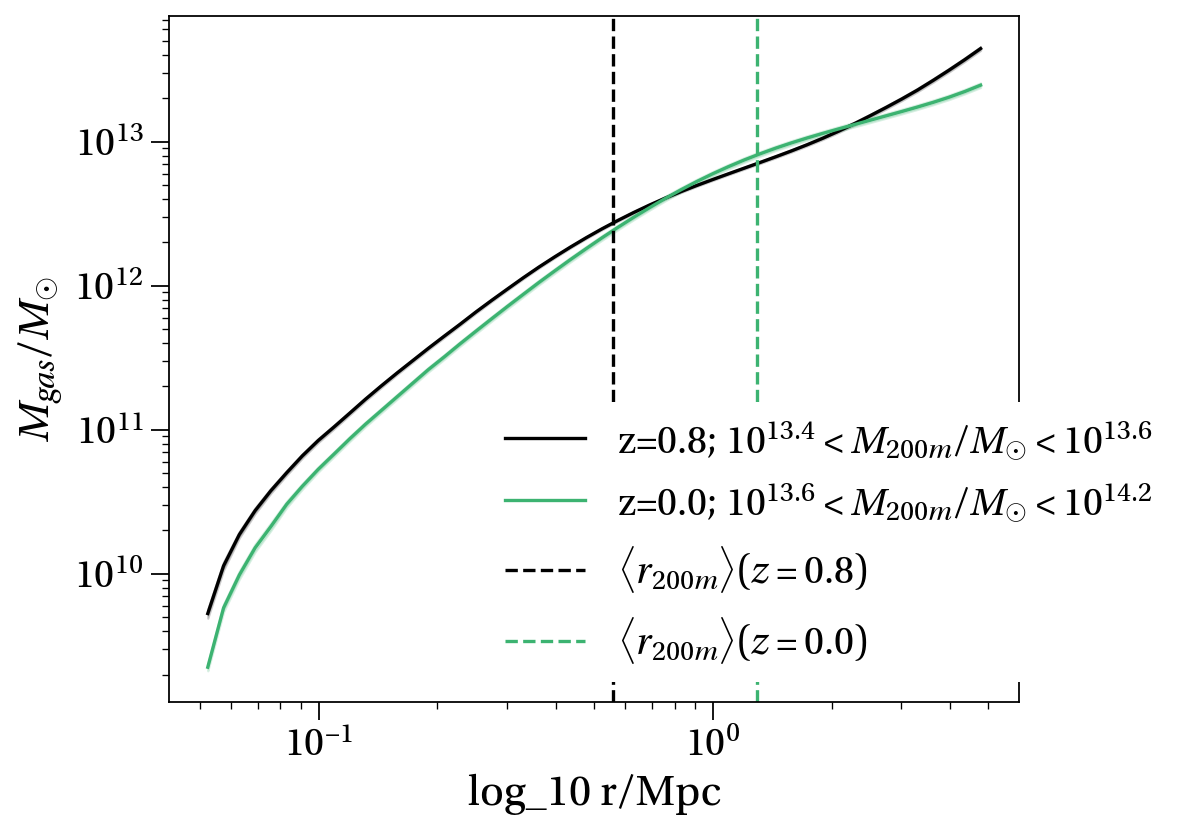

In [4]:
def make_mass_growth_explainer(start_ts=2, end_ts=8, M_min=13.4, M_max=13.6, particle='gas'):
    earlier_ts = end_ts - start_ts
    fa.make_plot('mass_enclosed', particle=particle, relative=False, M_min=M_min, M_max=M_max, 
                get_stack_kwargs={'timestep_name': f"%FIDUCIAL%/%{start_ts}.hdf5"},
                plot_kwargs={'color': 'black', 'linestyle':'-'})

    fa.make_plot('mass_enclosed', particle=particle, relative=False, M_min=M_min, M_max=M_max, 
                get_stack_kwargs={'timestep_name': f"%FIDUCIAL%/%{end_ts}.hdf5",
                                "M_name" : f'earlier({earlier_ts}).M200m()'},
                                plot_kwargs={'color': 'mediumseagreen', 'linestyle':'-'})

    M200, M200_final, r200, earlier_r200 = db.get_timestep(f"%FIDUCIAL%/%{end_ts}.hdf5").calculate_all(f"earlier({earlier_ts}).M200m()", "M200m()",
                                                                                           "r200m", f"earlier({earlier_ts}).r200m")
    mask = (np.log10(M200) >= M_min) & (np.log10(M200) <= M_max)

    earlier_mean_r200 = earlier_r200[mask].mean()
    mean_r200 = r200[mask].mean()

    
    p.axvline(earlier_mean_r200/1000, color='black', linestyle='--')
    p.axvline(mean_r200/1000, color='mediumseagreen', linestyle='--')

    z_start = db.get_timestep(f"%FIDUCIAL%/%{start_ts}.hdf5").redshift
    z_end = db.get_timestep(f"%FIDUCIAL%/%{end_ts}.hdf5").redshift

    late_M200_min, late_M200_max = np.percentile(np.log10(M200_final[mask]), [5,95])
    leg = p.legend([f"z={z_start:.1f}; $10^{{{M_min}}} < M_{{200m}}/M_{{\\odot}} < 10^{{{M_max}}}$", 
                    f"z={z_end:.1f}; $10^{{{late_M200_min:.1f}}} < M_{{200m}}/M_{{\\odot}} < 10^{{{late_M200_max:.1f}}}$",
                    fr"$\langle r_{{200m}} \rangle(z={z_start:.1f})$",
                    fr"$\langle r_{{200m}} \rangle(z={z_end:.1f})$"],
                   loc='lower right', frameon=True, bbox_to_anchor=(1.0, 0.0), bbox_transform=p.gca().transAxes)
    leg.set_bbox_to_anchor((1.2, 0.0), transform=p.gca().transAxes)
    frame = leg.get_frame()
    frame.set_facecolor('white')
    frame.set_alpha(1.0)

make_mass_growth_explainer(start_ts=2, end_ts=8, M_min=13.4, M_max=13.6)

Text(0, 0.5, '$M_{gas}/M_{DM}$')

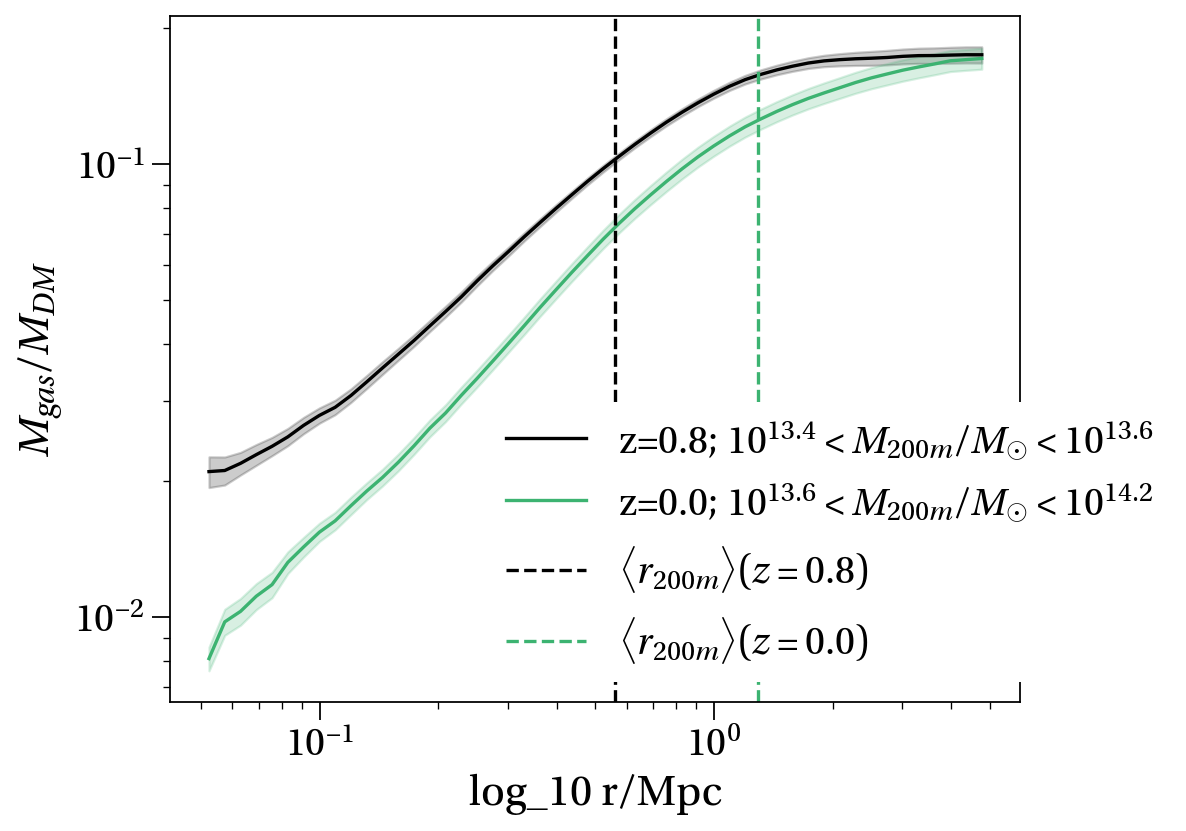

In [5]:
make_mass_growth_explainer(start_ts=2, end_ts=8, M_min=13.4, M_max=13.6, particle='ratio')
p.ylabel('$M_{gas}/M_{DM}$')

Plotting mdot_outflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5
Plotting mdot_inflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5


Text(2.3, 600, '')

<Figure size 960x400 with 0 Axes>

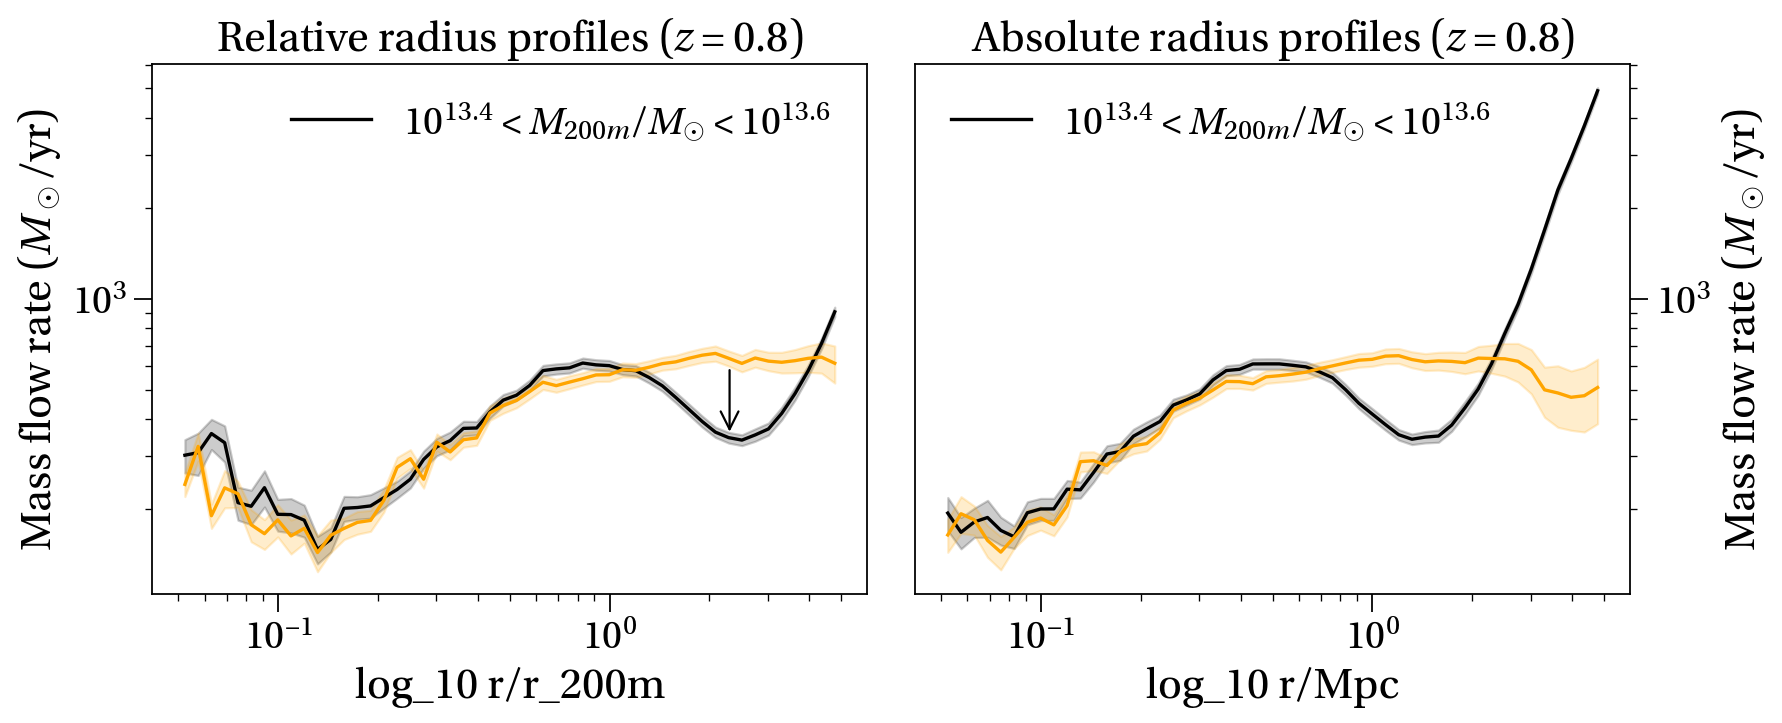

In [6]:
def make_mass_flow_rate_comparator(particle='gas', M_min=13.4, M_max=13.6):
    p.figure(figsize=(12,5))
    fa.make_profile_plots('mdot_outflow', particle=particle, tsnum=2, box="L0200N0360_HYDRO_FIDUCIAL",
                        plot_kwargs={'color': 'black'}, ranges_override=[(M_min, M_max)],)
    fa.make_profile_plots('mdot_inflow', particle=particle, tsnum=2, box="L0200N0360_HYDRO_FIDUCIAL", 
                        plot_kwargs={'color':'orange'}, newfig=False, ranges_override=[(M_min, M_max)],)

    p.subplot(122)
    ylims = p.ylim()
    p.ylabel(r"Mass flow rate ($M_\odot$/yr)")
    p.subplot(121)
    p.ylim(ylims)
    p.ylabel(r"Mass flow rate ($M_\odot$/yr)")

make_mass_flow_rate_comparator()
p.annotate('', xy=(2.3, 350), xytext=(2.3, 600), 
           arrowprops=dict(arrowstyle='->', color='black'))


Plotting mdot_outflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5
Plotting mdot_inflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5


Text(53.73402777777781, 0.5, 'Mass flow rate ($M_\\odot$/yr)')

<Figure size 960x400 with 0 Axes>

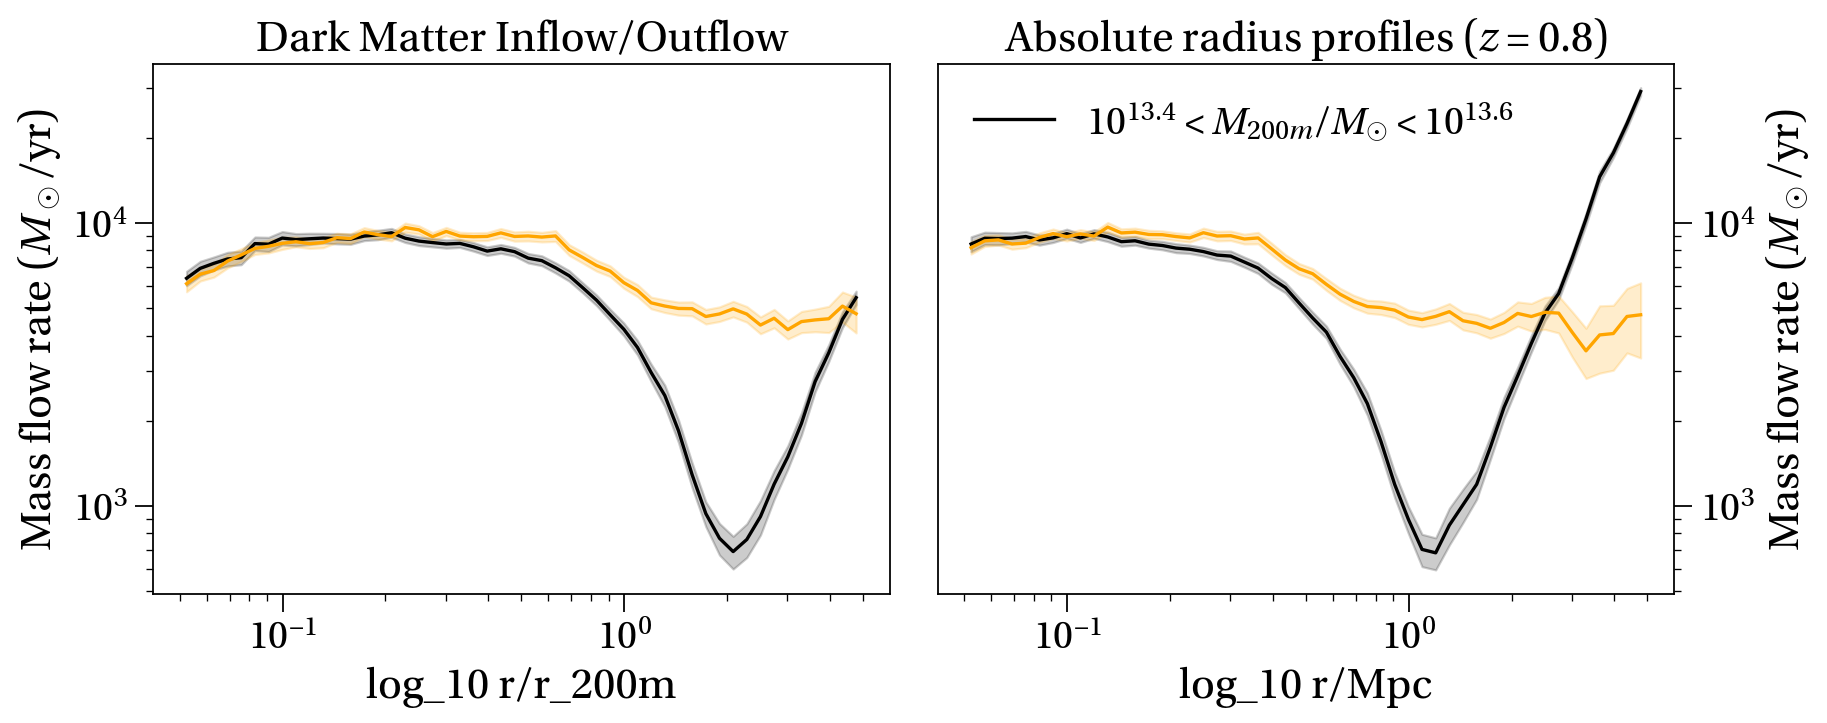

In [7]:
make_mass_flow_rate_comparator(particle='dm')
p.subplot(121)
fa.remove_existing_legend()
p.title("Dark Matter Inflow/Outflow")
p.ylabel(r"Mass flow rate ($M_\odot$/yr)")

Plotting mdot_outflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5
Plotting mdot_inflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5


<Figure size 960x400 with 0 Axes>

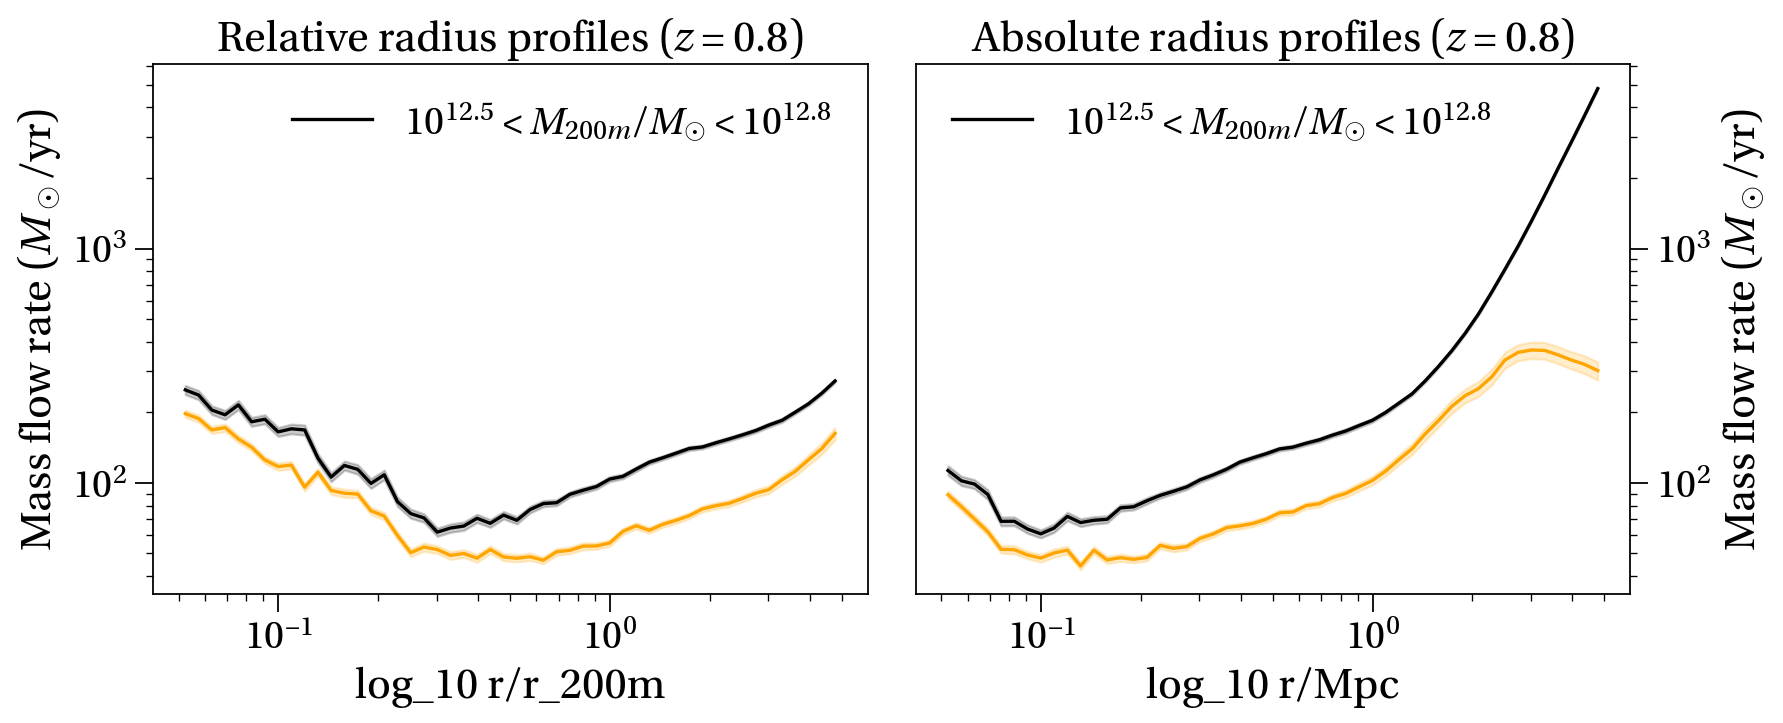

In [8]:
make_mass_flow_rate_comparator(M_min=12.5, M_max=12.8)

Text(0.5, 1.0, '')

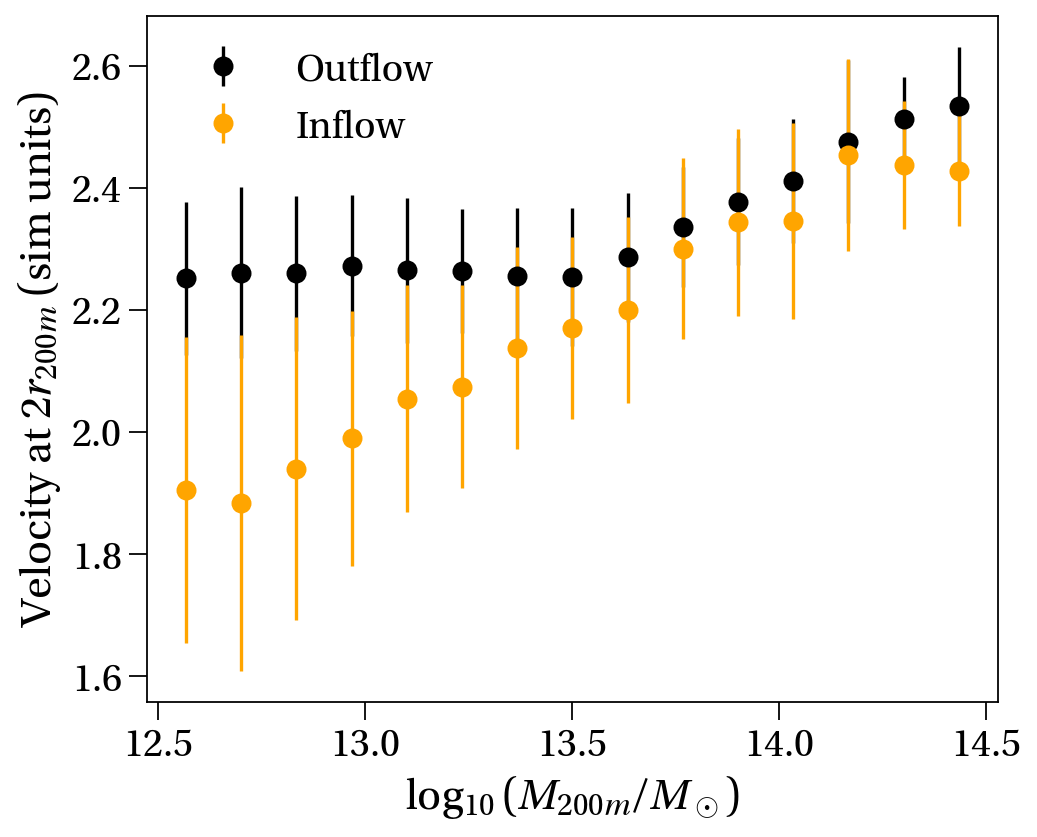

In [69]:
fa.make_binned_by_mass_plot('log10(at(0.301, gas_vr_outflow_r200m_relative))', 
                            plot_kwargs={'color': 'black'}, ts_name=f"%FIDUCIAL%/%8.hdf5")
fa.make_binned_by_mass_plot('log10(0.0-at(0.301, gas_vr_inflow_r200m_relative))', 
                            plot_kwargs={'color': 'orange'}, ts_name=f"%FIDUCIAL%/%8.hdf5")
p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
p.ylabel(r"Velocity at 2$r_{200m}$ (sim units)")
p.legend(['Outflow', 'Inflow'])
p.title("")

Plotting vr_outflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5
Plotting vr_inflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5
Plotting cs profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5
Plotting vr_outflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5
Plotting vr_inflow profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5
Plotting cs profiles for L0200N0360_HYDRO_FIDUCIAL/%2.hdf5


<Figure size 960x400 with 0 Axes>

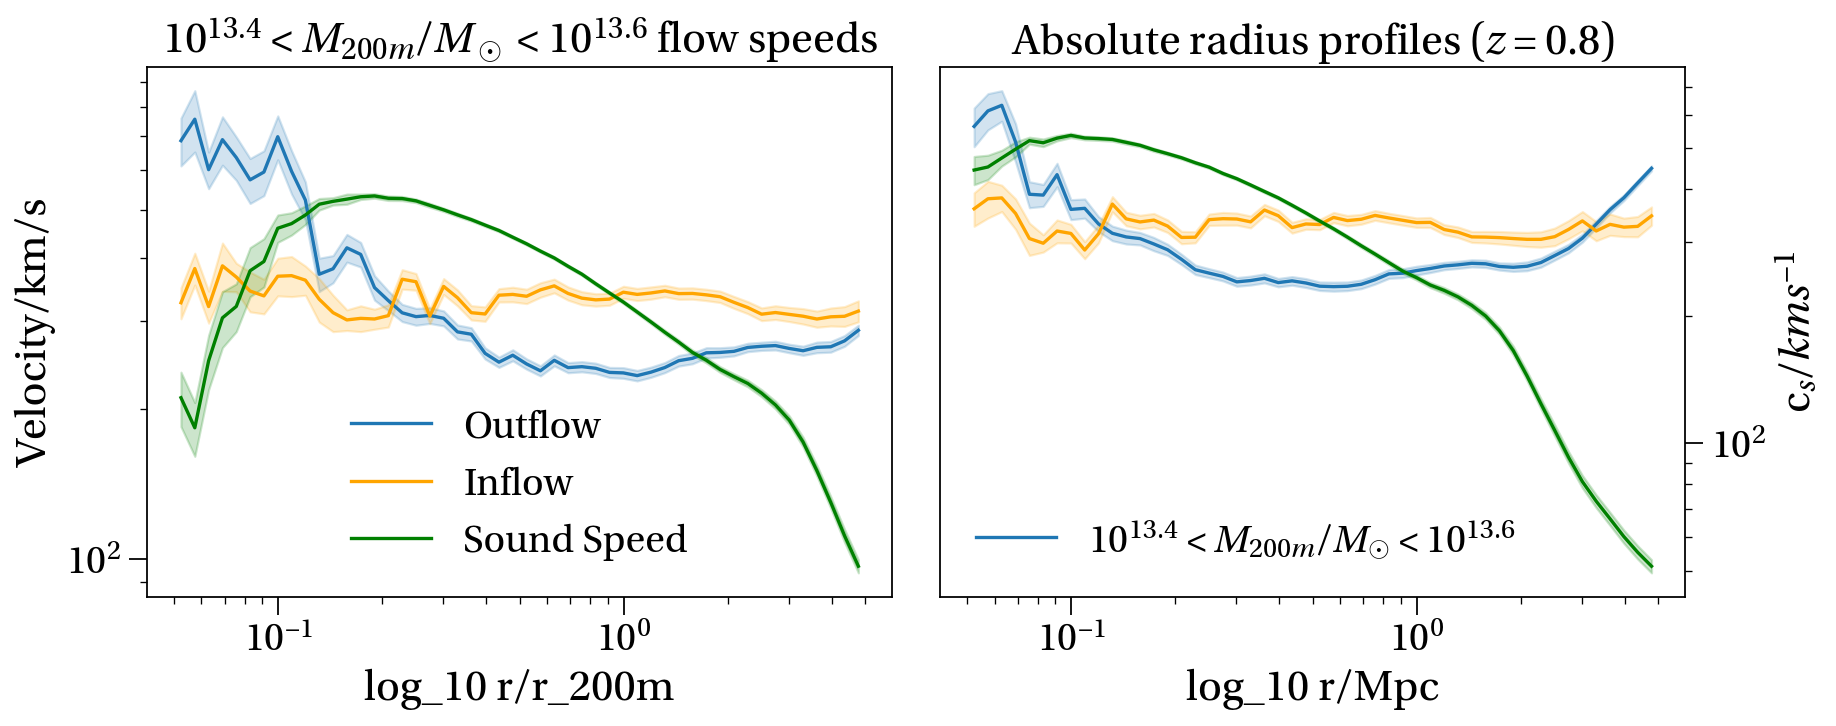

<Figure size 960x400 with 0 Axes>

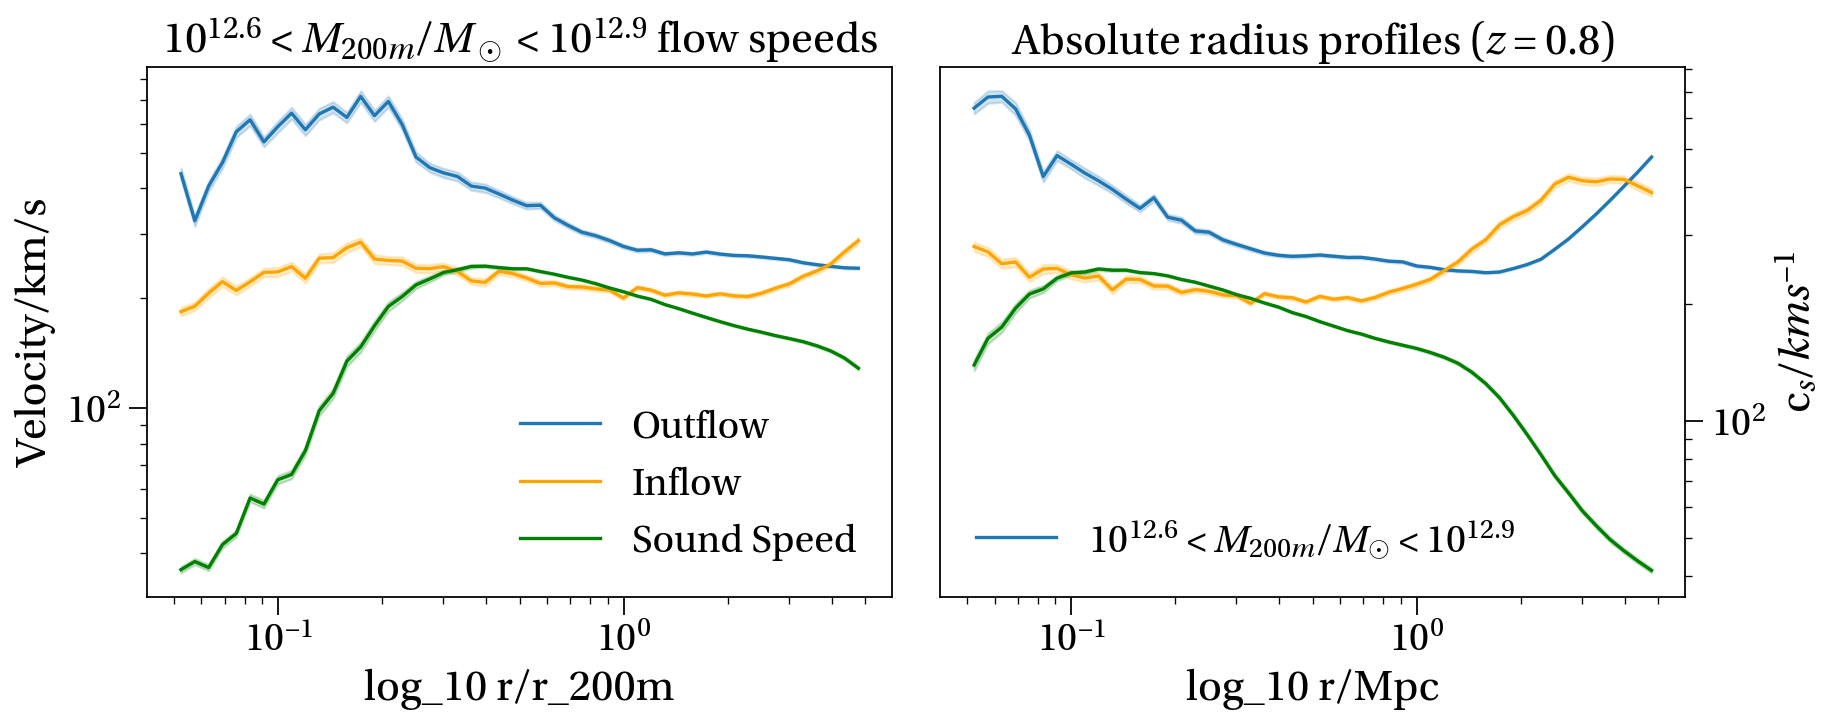

In [7]:
def make_outflow_inflow_cs_plot(range_override):
    p.figure(figsize=(12,5))
    fa.make_profile_plots('vr_outflow', particle='gas', tsnum=2, box="L0200N0360_HYDRO_FIDUCIAL", weight_by='mdot_outflow',
                        ranges_override=[range_override])
    fa.make_profile_plots('vr_inflow', particle='gas', tsnum=2, box="L0200N0360_HYDRO_FIDUCIAL", newfig=False, 
                        weight_by='mdot_inflow', plot_kwargs={'color': 'orange'}, ranges_override=[range_override])
    fa.make_profile_plots('cs', particle='gas', tsnum=2, box="L0200N0360_HYDRO_FIDUCIAL", 
                        ranges_override=[range_override], plot_kwargs={'color':'green'}, newfig=False)
    p.subplot(121)
    fa.remove_existing_legend()
    p.legend(['Outflow', 'Inflow', 'Sound Speed'])
    p.ylabel("Velocity/km/s")
    p.title(f"$10^{{{range_override[0]}}} < M_{{200m}}/M_\\odot < 10^{{{range_override[1]}}}$ flow speeds")

make_outflow_inflow_cs_plot((13.4, 13.6))
make_outflow_inflow_cs_plot((12.6, 12.9))

In [10]:
import virial_scalings as vs

In [7]:
def make_plot_at_radius(tsnum, property, at=1.0, relative=True, log=False, weight=False, boxname=r"%FIDUCIAL%"):
    log_at = np.log10(at)
    suffix = "_r200m_relative" if relative else ""
    outflow_full_property_name = f'at({log_at}, {property}_outflow{suffix})'
    inflow_full_property_name = f'at({log_at}, {property}_inflow{suffix})'
    if log:
        outflow_full_property_name = f'log10(abs({outflow_full_property_name}))'
        inflow_full_property_name = f'log10(abs({inflow_full_property_name}))'
    else:
        outflow_full_property_name = f'abs({outflow_full_property_name})'
        inflow_full_property_name = f'abs({inflow_full_property_name})'
    fa.make_binned_by_mass_plot(outflow_full_property_name, 
                                plot_kwargs={'color': 'black'},
                                ts_name=f"{boxname}/%{tsnum}.hdf5",
                                weight_property_name=f'at({log_at}, gas_mdot_outflow{suffix})' if weight else None)
    fa.make_binned_by_mass_plot(inflow_full_property_name, 
                                plot_kwargs={'color': 'orange'},
                                ts_name=f"{boxname}/%{tsnum}.hdf5",
                                weight_property_name=f'at({log_at}, gas_mdot_inflow{suffix})' if weight else None)
    p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
    location_label = f"at {at:.1f} $r_{{200m}}$" if relative else f"{at:.1f} Mpc"
    p.ylabel(rf"{property.replace('_', ' ').title()} at {location_label}")
    p.title("")

def make_virial_entropy_plot(tsnum, at=1.0, relative=True, boxname=r"%FIDUCIAL%"):
    log_at = np.log10(at)
    make_plot_at_radius(tsnum, 'gas_entropy', at=at, relative=relative, boxname=boxname)
    p.title("")

    z = db.get_timestep(f"{boxname}/%{tsnum}.hdf5").redshift
    K1 = (vs.entropy(10**12.5, z=z))
    K2 = (vs.entropy(10**14.5, z=z))

    p.plot([12.5, 14.5], [K1, K2], color='red', linestyle='--')
    p.title(f"z={z:.1f}")
    p.legend(['Virial', 'Outflow', 'Inflow'])
    p.semilogy()

1.32e+07 G**4/3 Mpc**2/3 Msol**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Mpc**2/3 Msol**2/3 s**2/3 km**-2/3


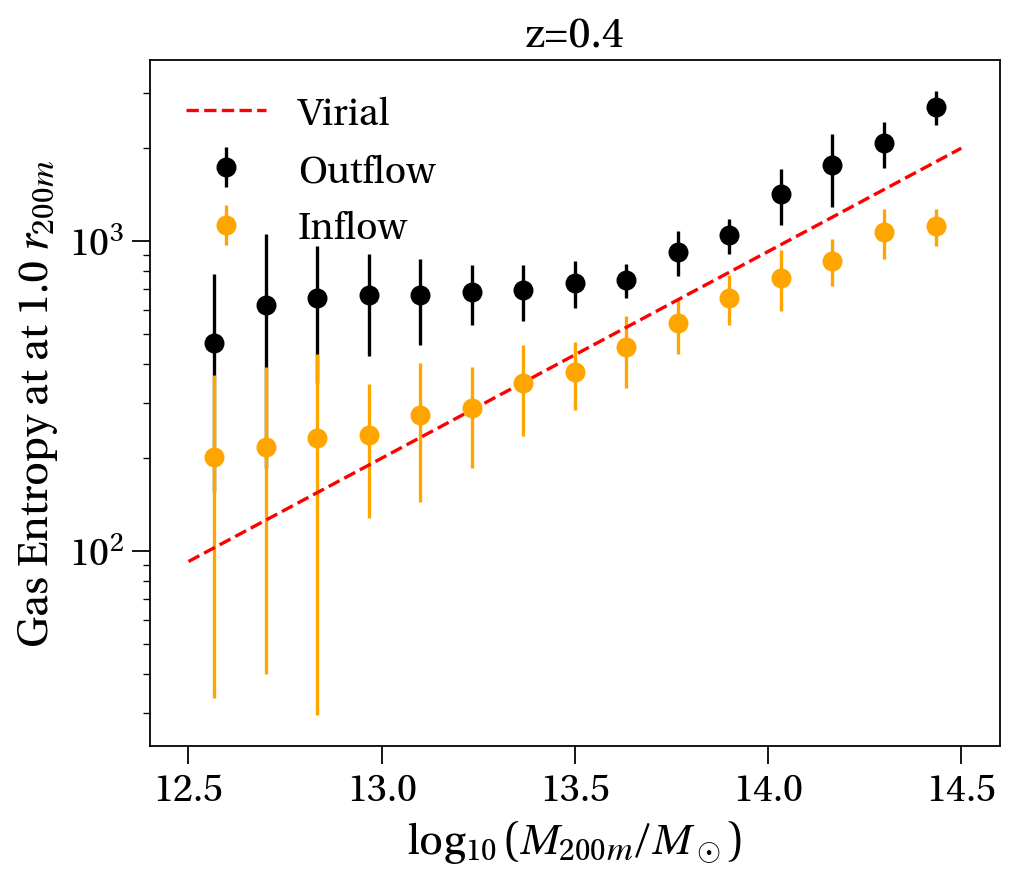

In [48]:
make_virial_entropy_plot(tsnum=4, relative=True, at=1.0)

In [15]:
db.init_db('data.db')

def labels_on_right():
    ax = p.gca()
    ax.yaxis.set_ticks_position('both')
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_tick_params(labelleft=False, labelright=True)

def make_outflow_diagnostic_plots(tsnum=4, boxname=r"%FIDUCIAL%", radii=[0.1, 1.0, 2.0]):
    n_radii = len(radii)
    p.figure(figsize=(n_radii*5, 15))
    
    for i, radius in enumerate(radii):
        # Entropy plots (row 1)
        p.subplot(4, n_radii, i+1)
        make_virial_entropy_plot(tsnum=tsnum, relative=True, boxname=boxname, at=radius)
        p.ylim(10, 3e3)
        if i == n_radii - 1:
            labels_on_right()
        
        # Velocity plots (row 2)
        p.subplot(4, n_radii, n_radii + i + 1)
        make_plot_at_radius(tsnum=tsnum, property='gas_vr', at=radius, relative=True, weight=True, boxname=boxname)
        p.semilogy()
        p.ylim(1e2, 5e3)
        log_radius = np.log10(radius)
        fa.make_binned_by_mass_plot(f'at({log_radius}, gas_cs_r200m_relative)')
        p.title("")
        if i == n_radii - 1:
            labels_on_right()
        
        # Temperature plots (row 3)
        p.subplot(4, n_radii, 2*n_radii + i + 1)
        make_plot_at_radius(tsnum=tsnum, property='gas_temp', at=radius, relative=True, weight=True, boxname=boxname)
        p.semilogy()
        p.ylim(1e4, 1e8)
        if i == n_radii - 1:
            labels_on_right()

        # outflow/inflow mass flux plots (row 4)
        p.subplot(4, n_radii, 3*n_radii + i + 1)
        outflow_by_mass(ts_name=f"{boxname}/%{tsnum}.hdf5", radius=radius)
        p.ylim(1, 1e4)
        if i == n_radii - 1:
            labels_on_right()


1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3


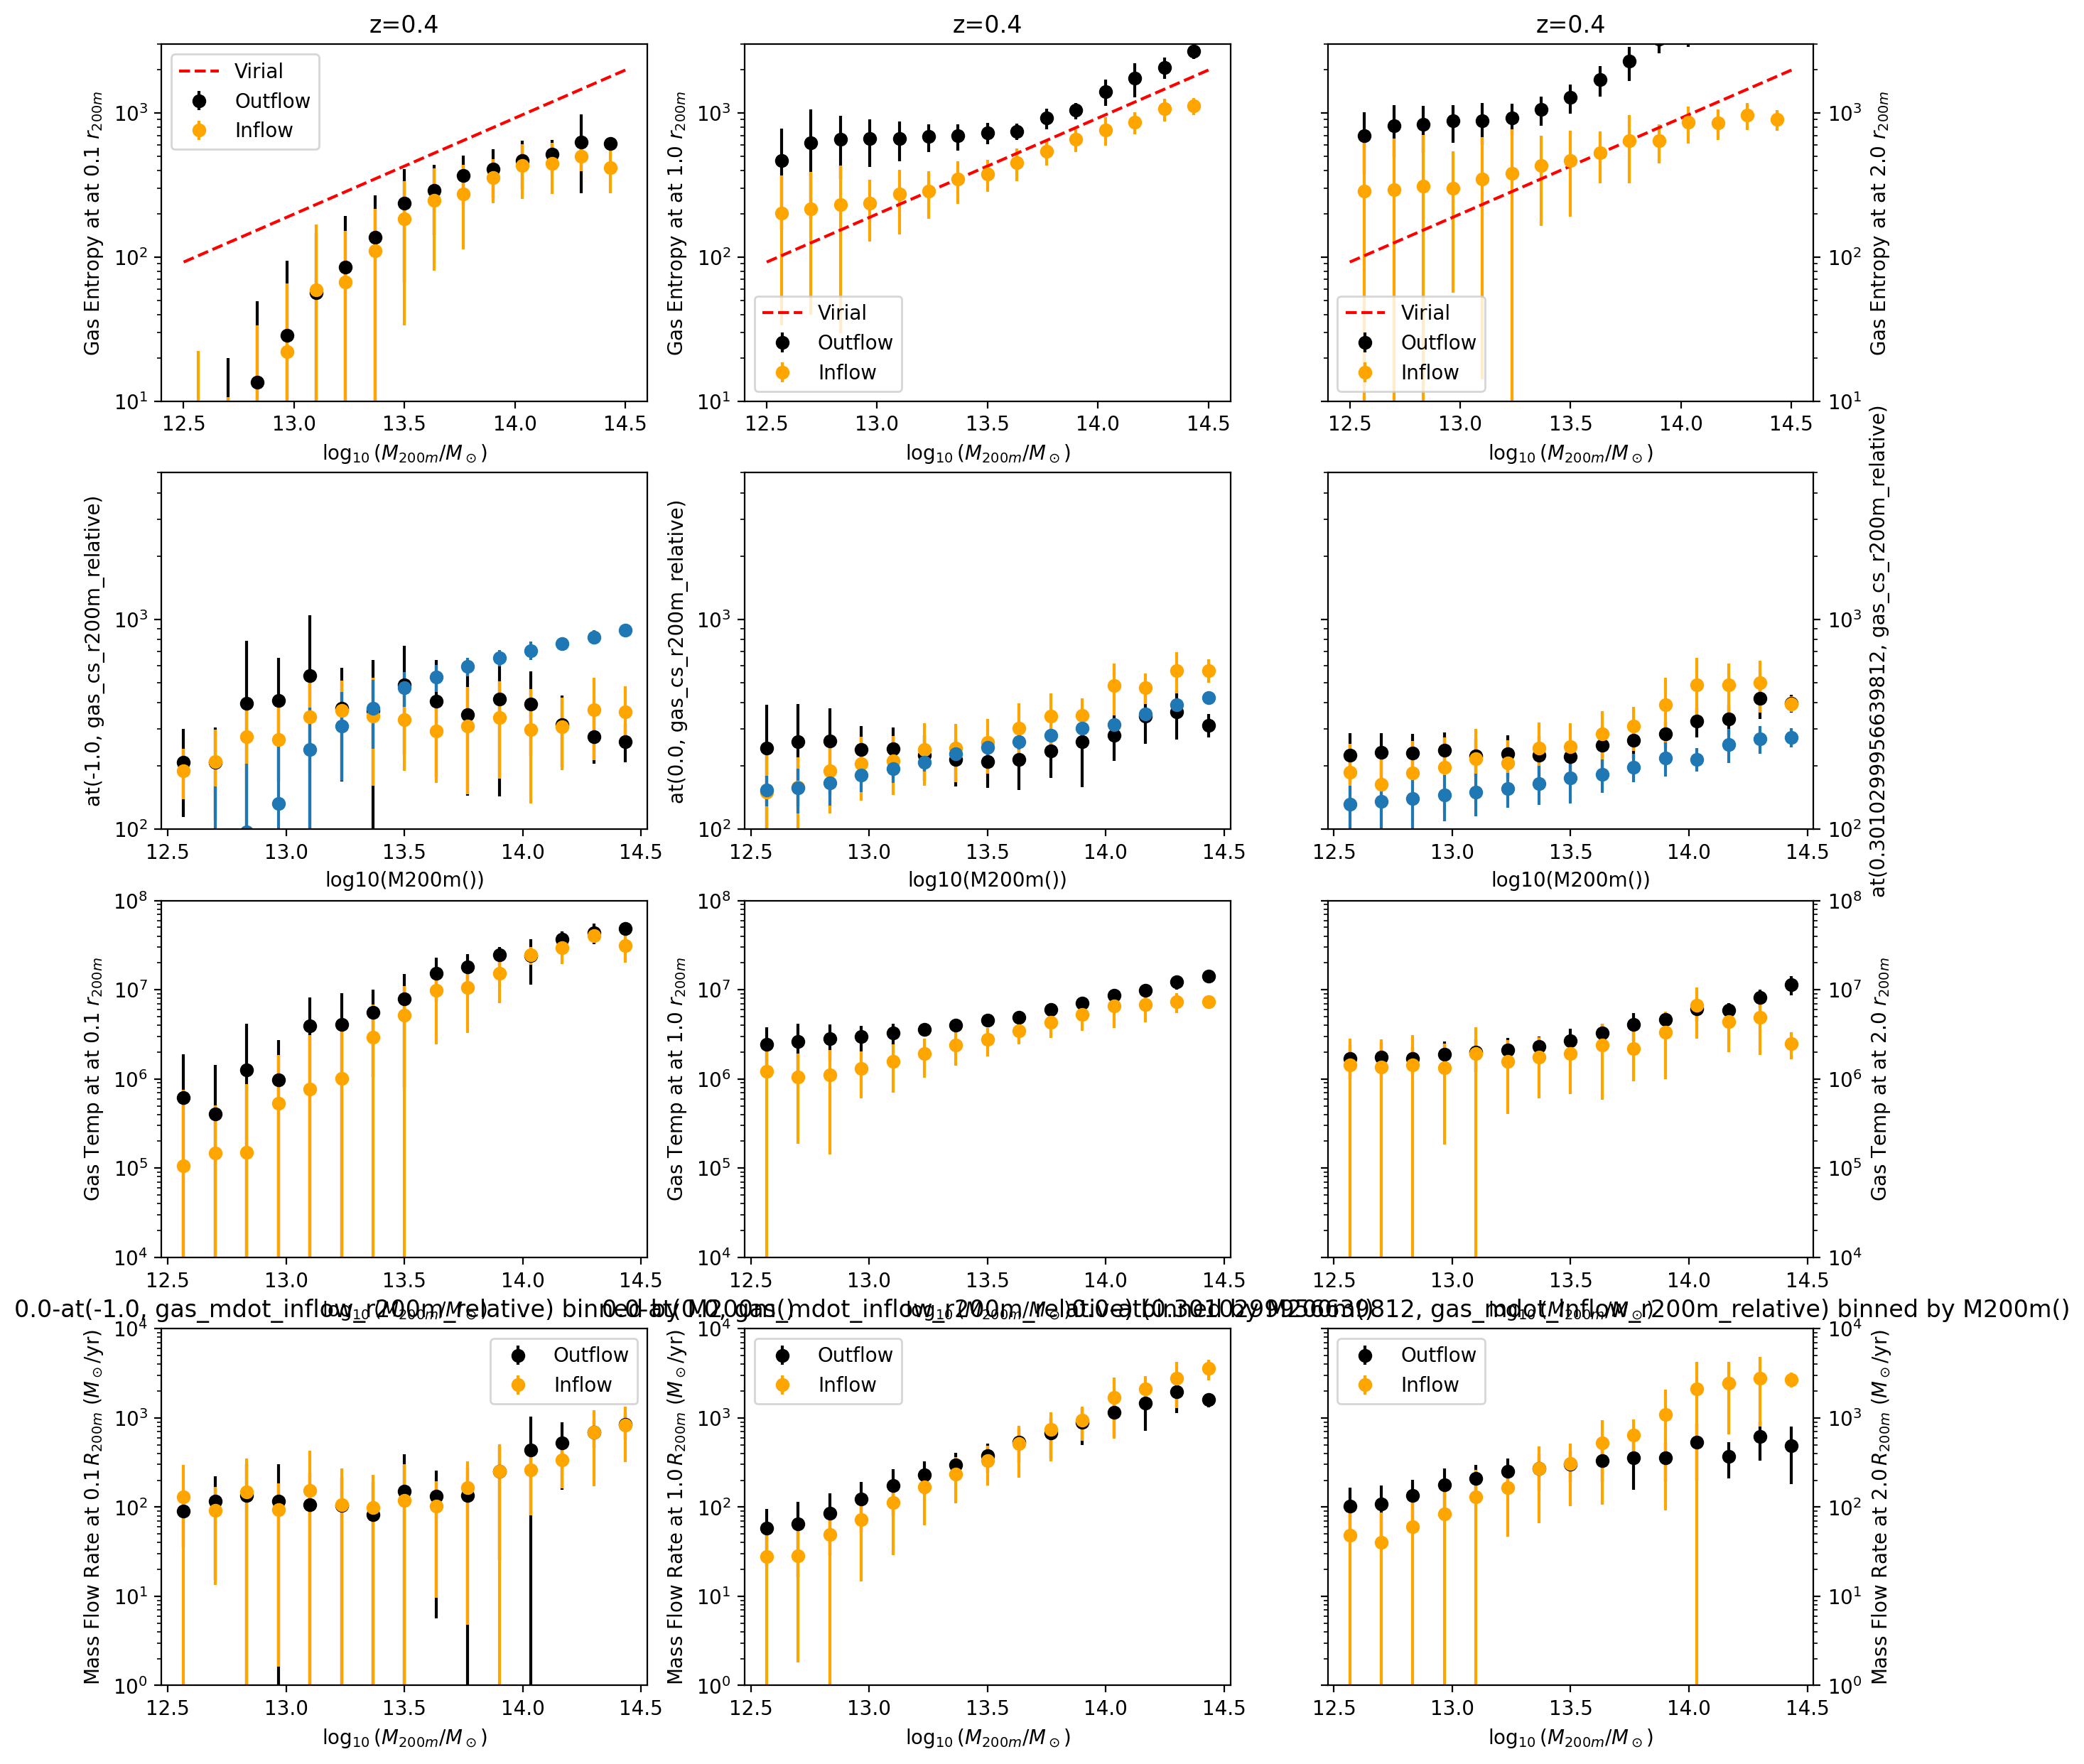

In [16]:
make_outflow_diagnostic_plots(tsnum=4, boxname="%FIDUCIAL%")

1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
1.32e+07 G**4/3 Msol**2/3 Mpc**2/3 s**2/3 km**-2/3
2.85e+08 G**4/3 Msol**2/3 Mpc**

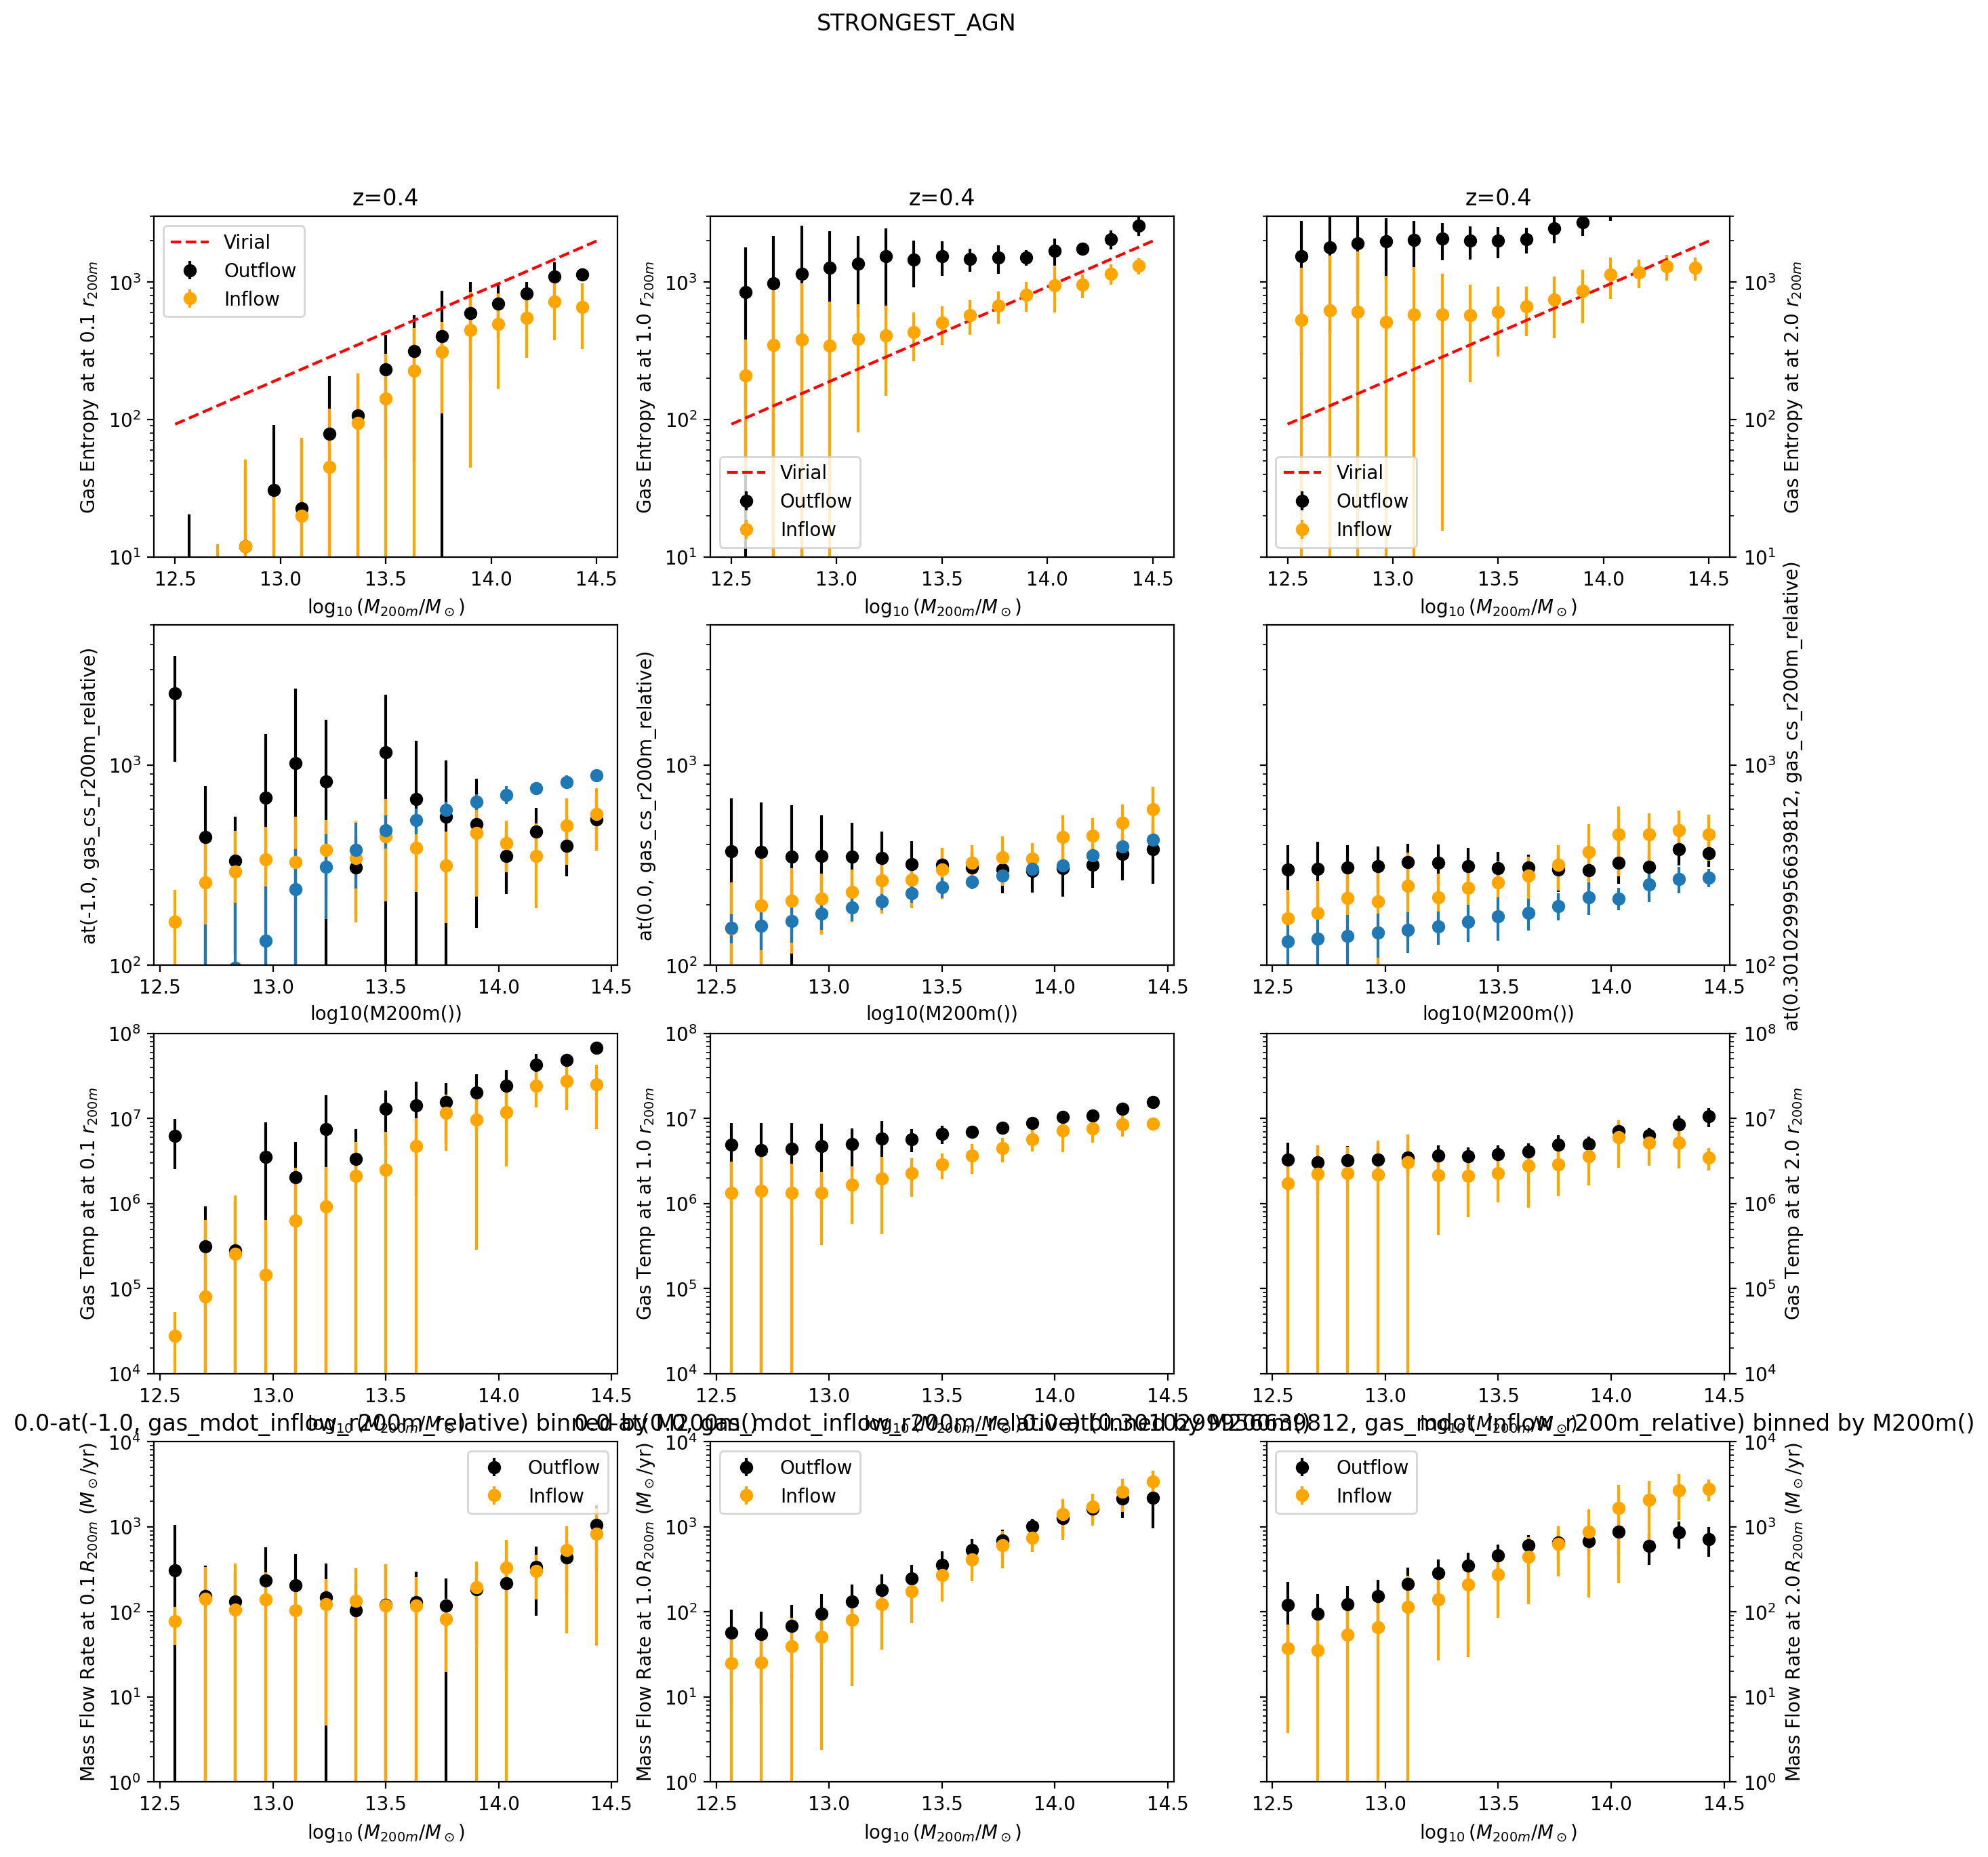

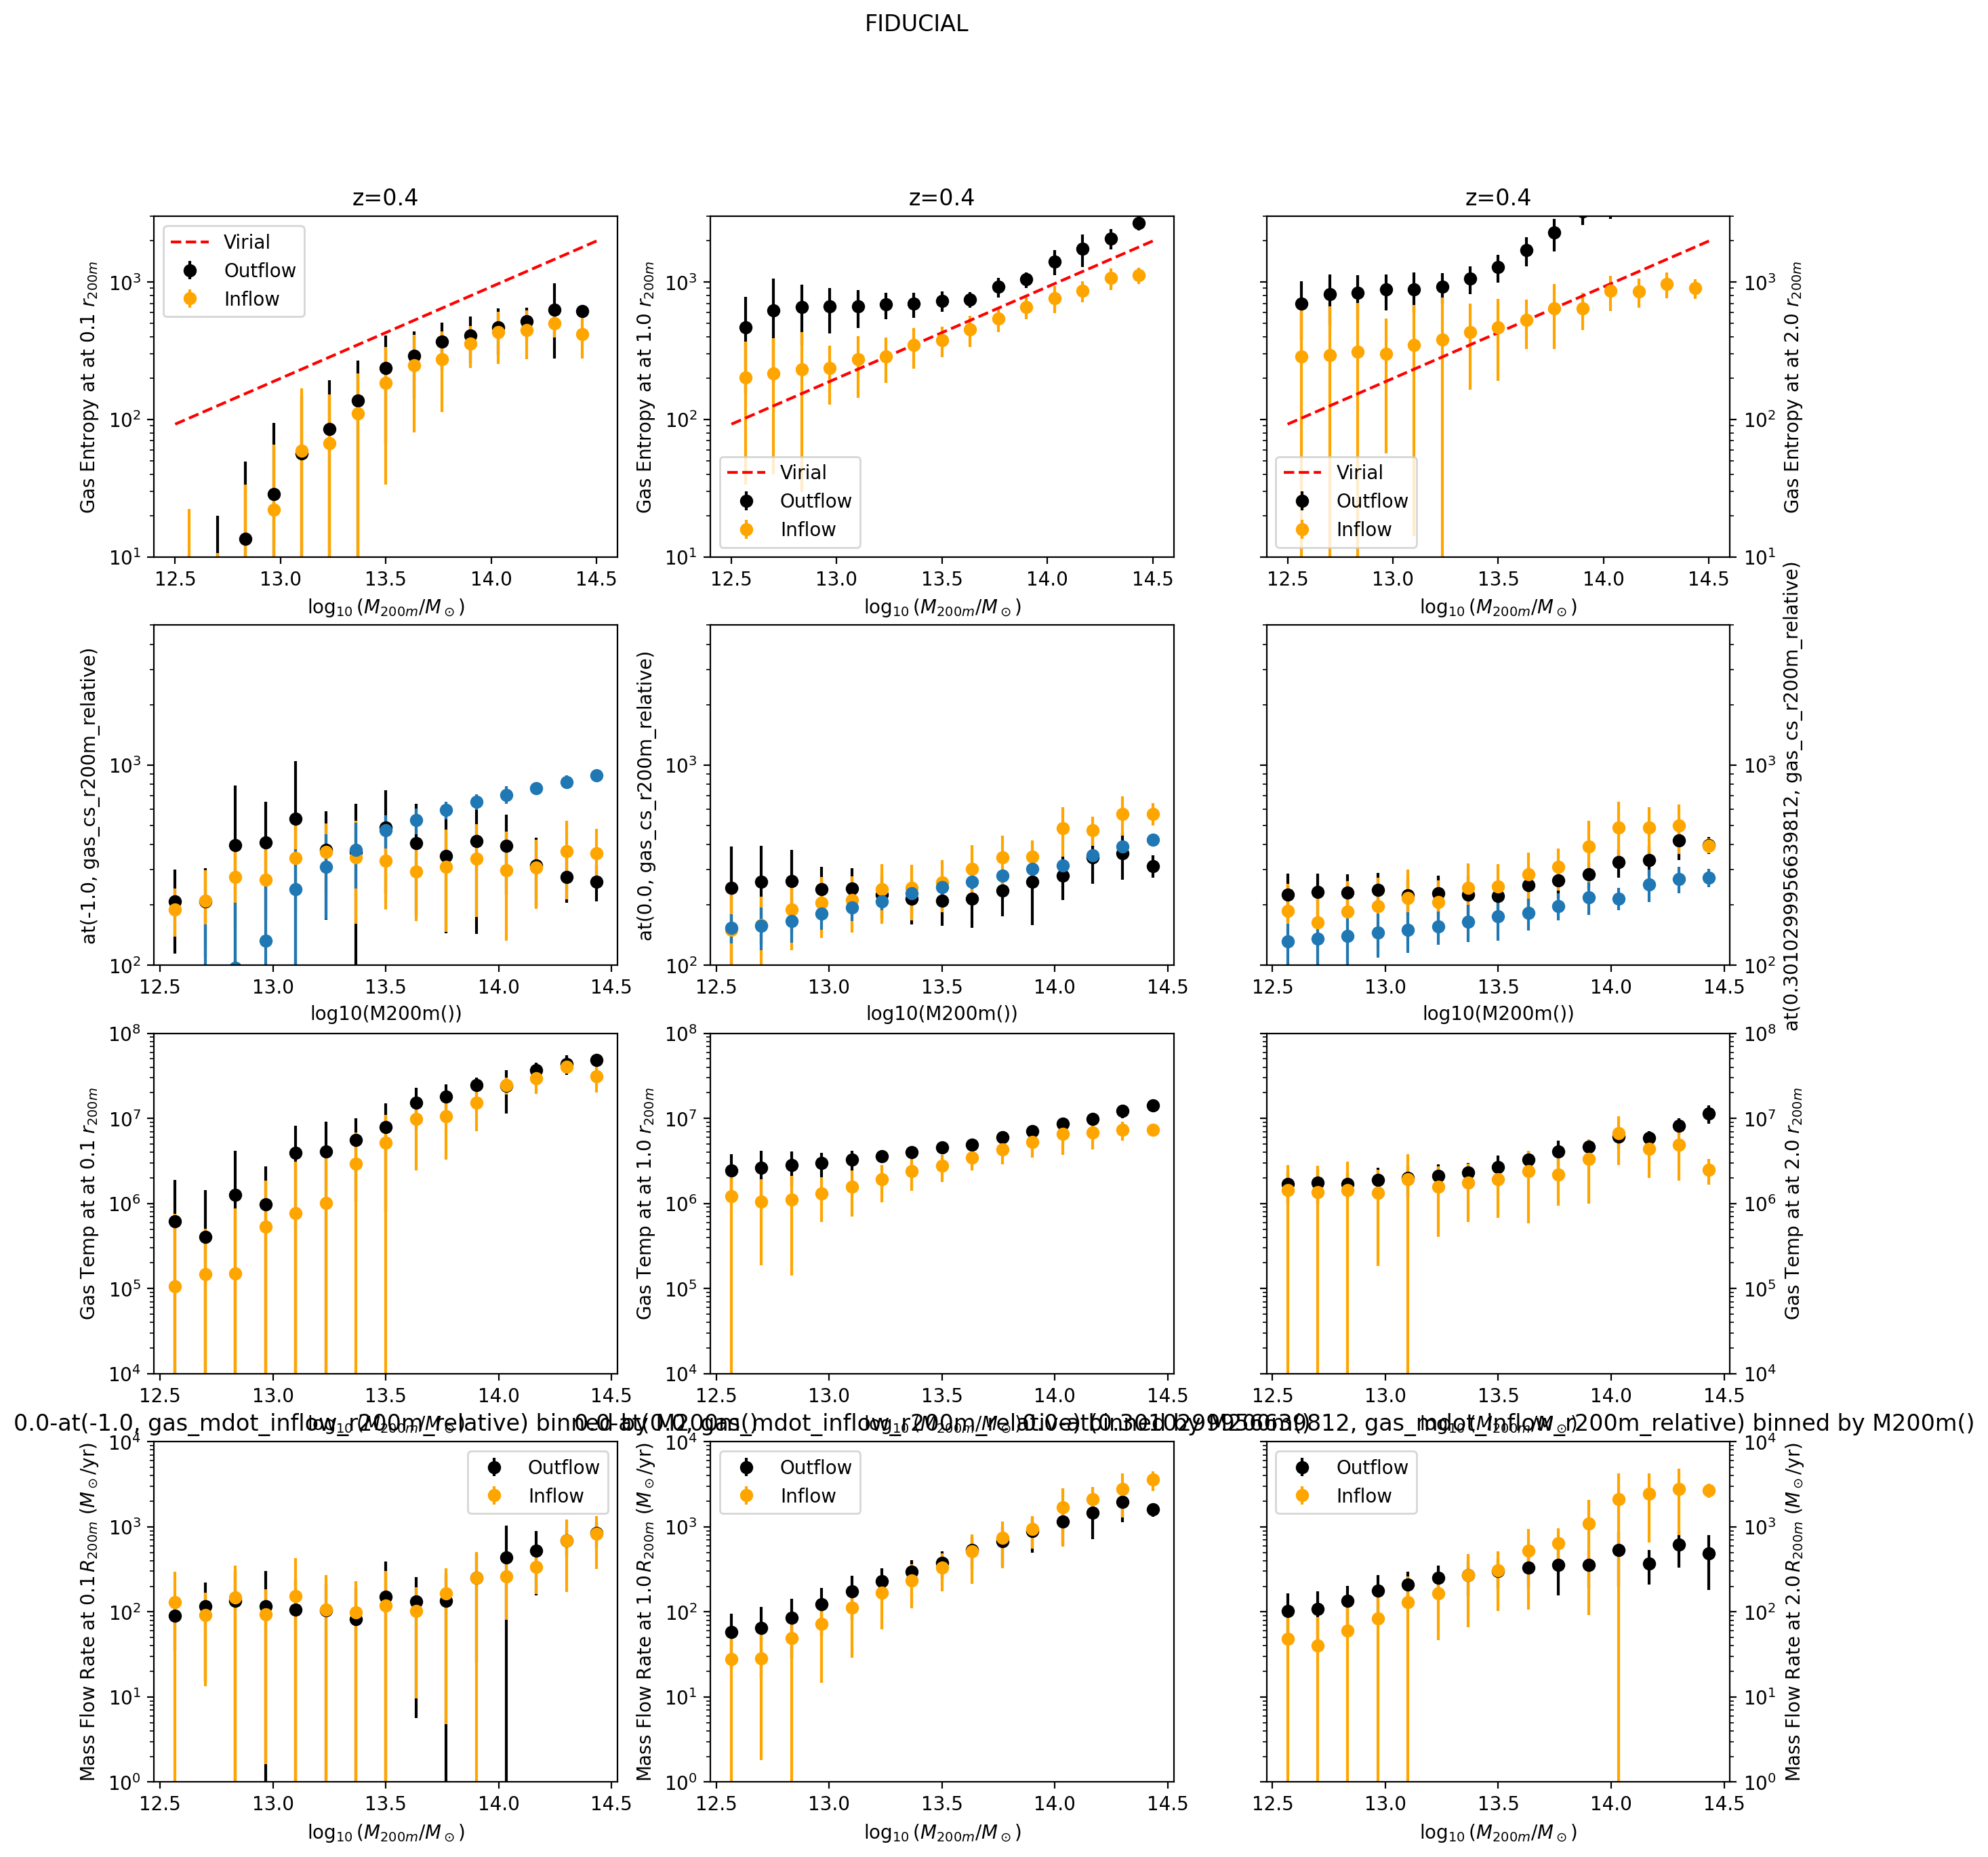

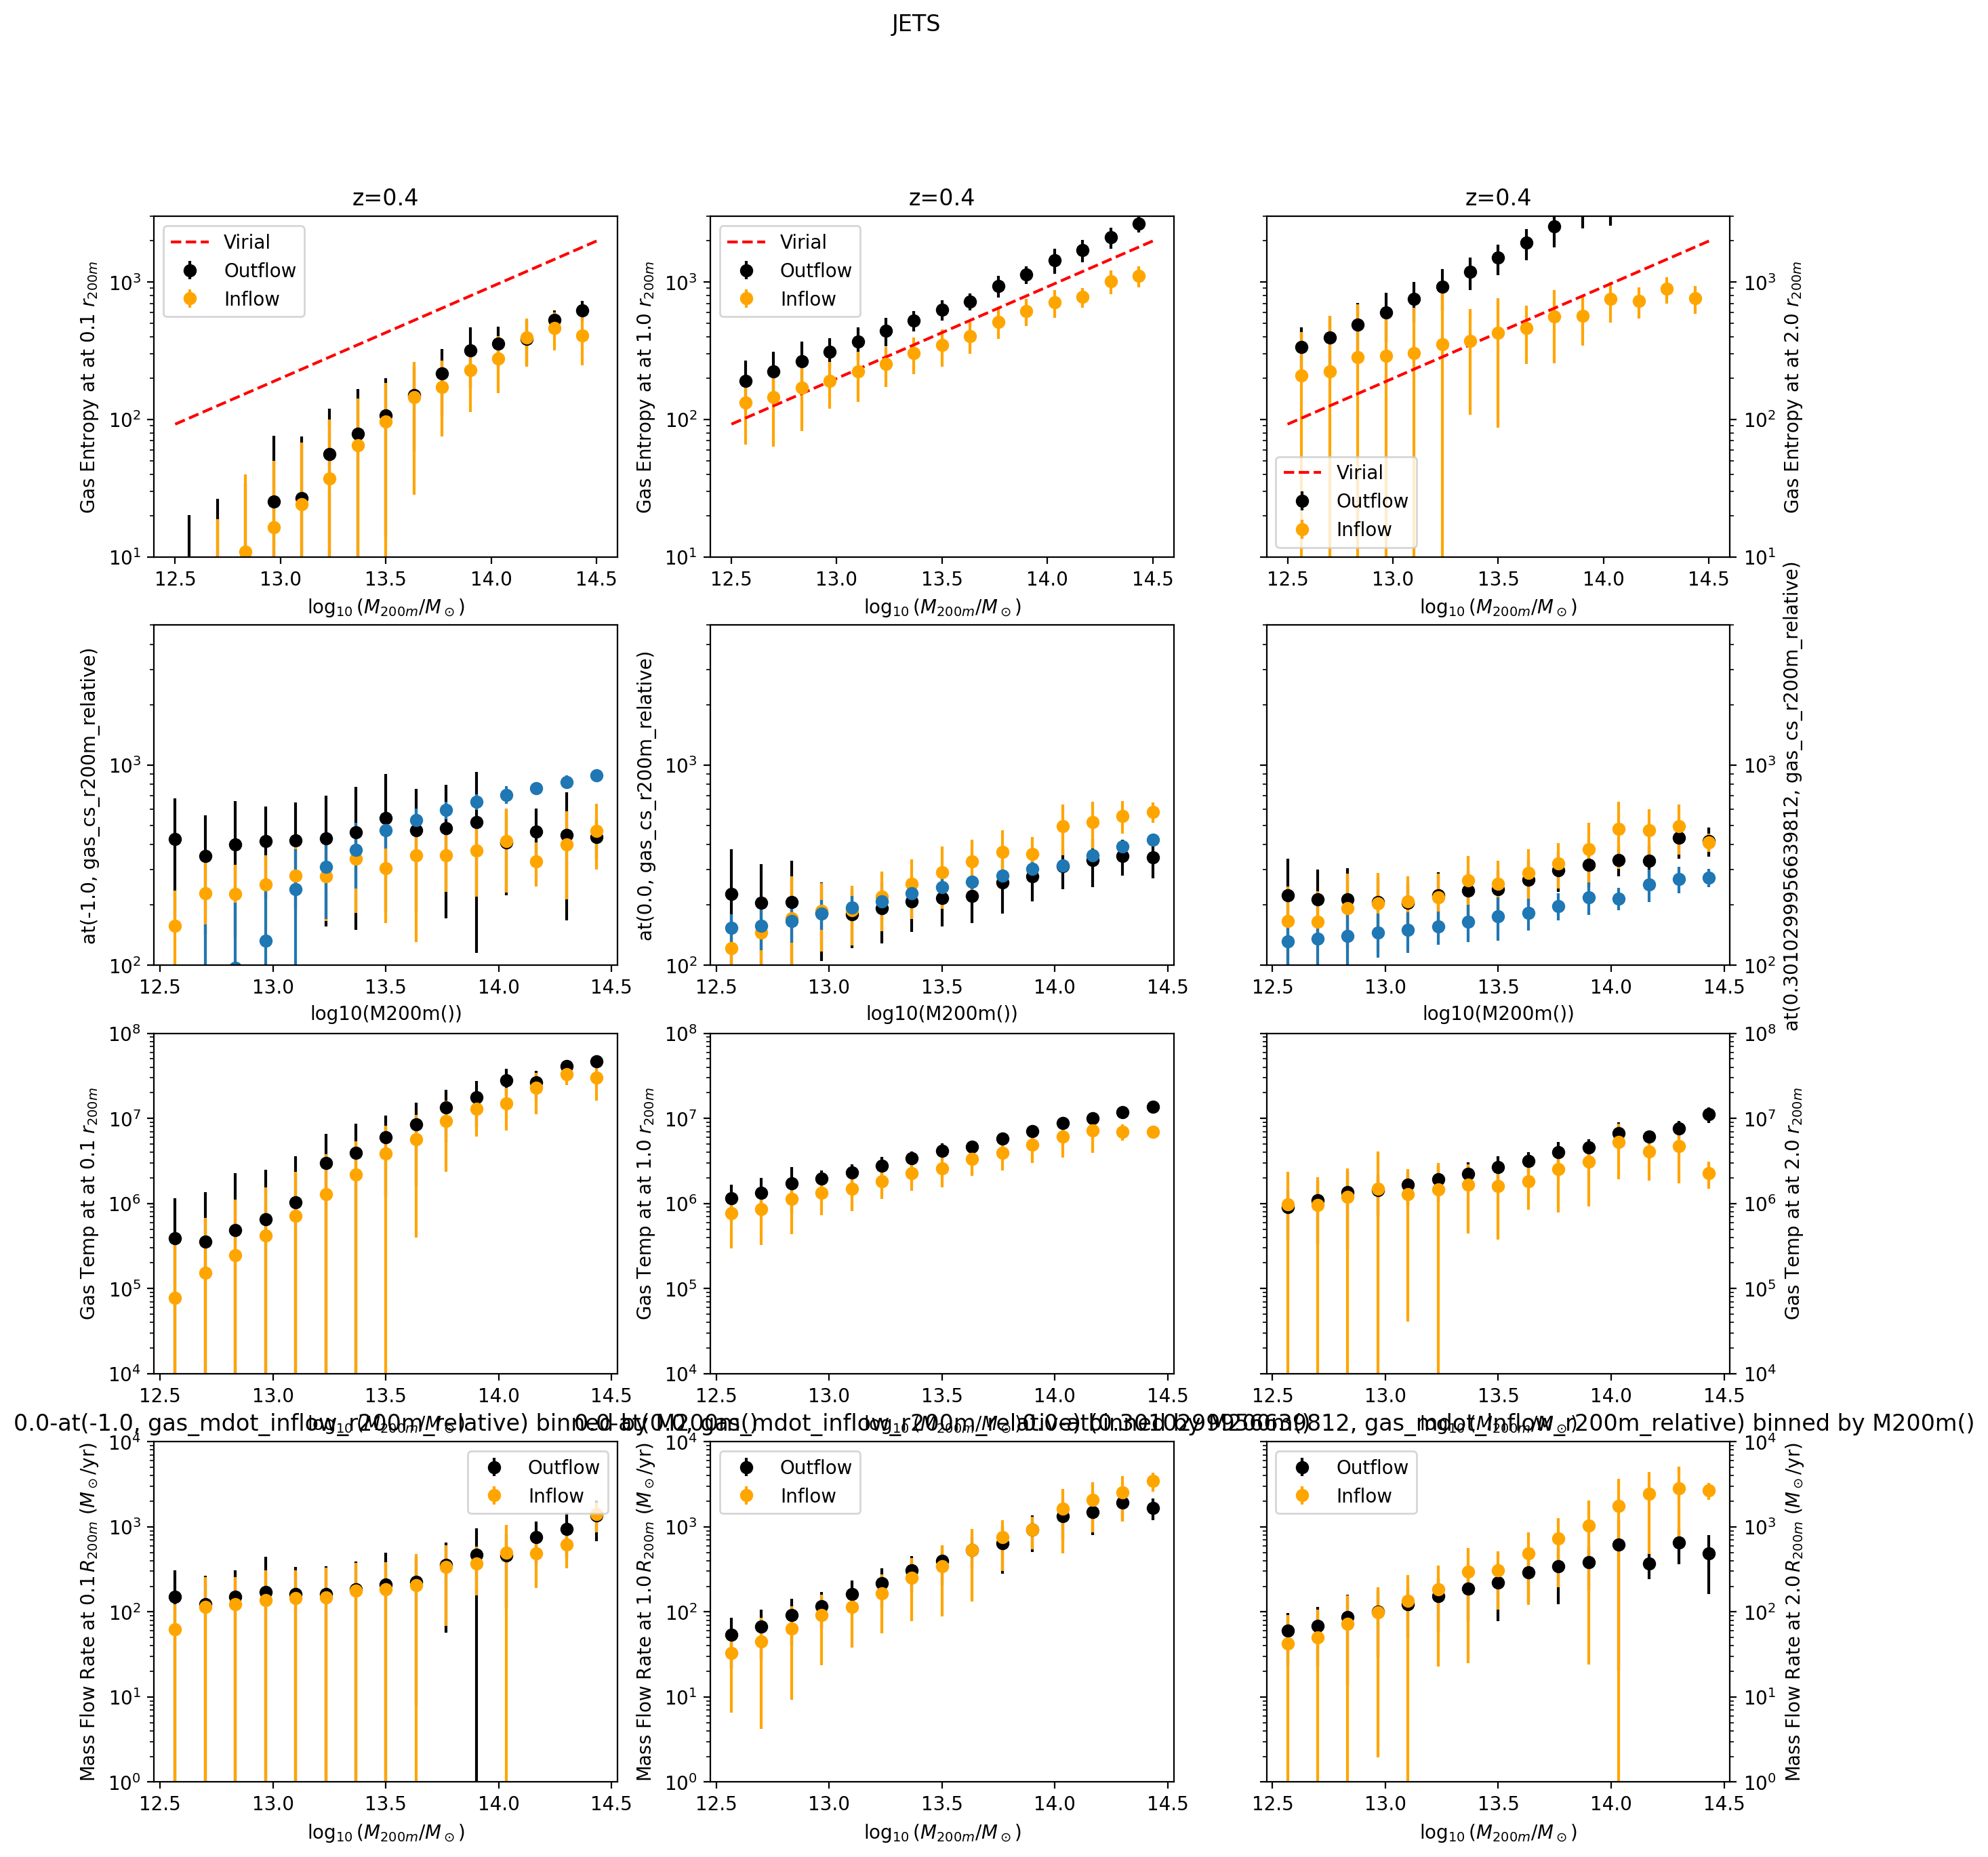

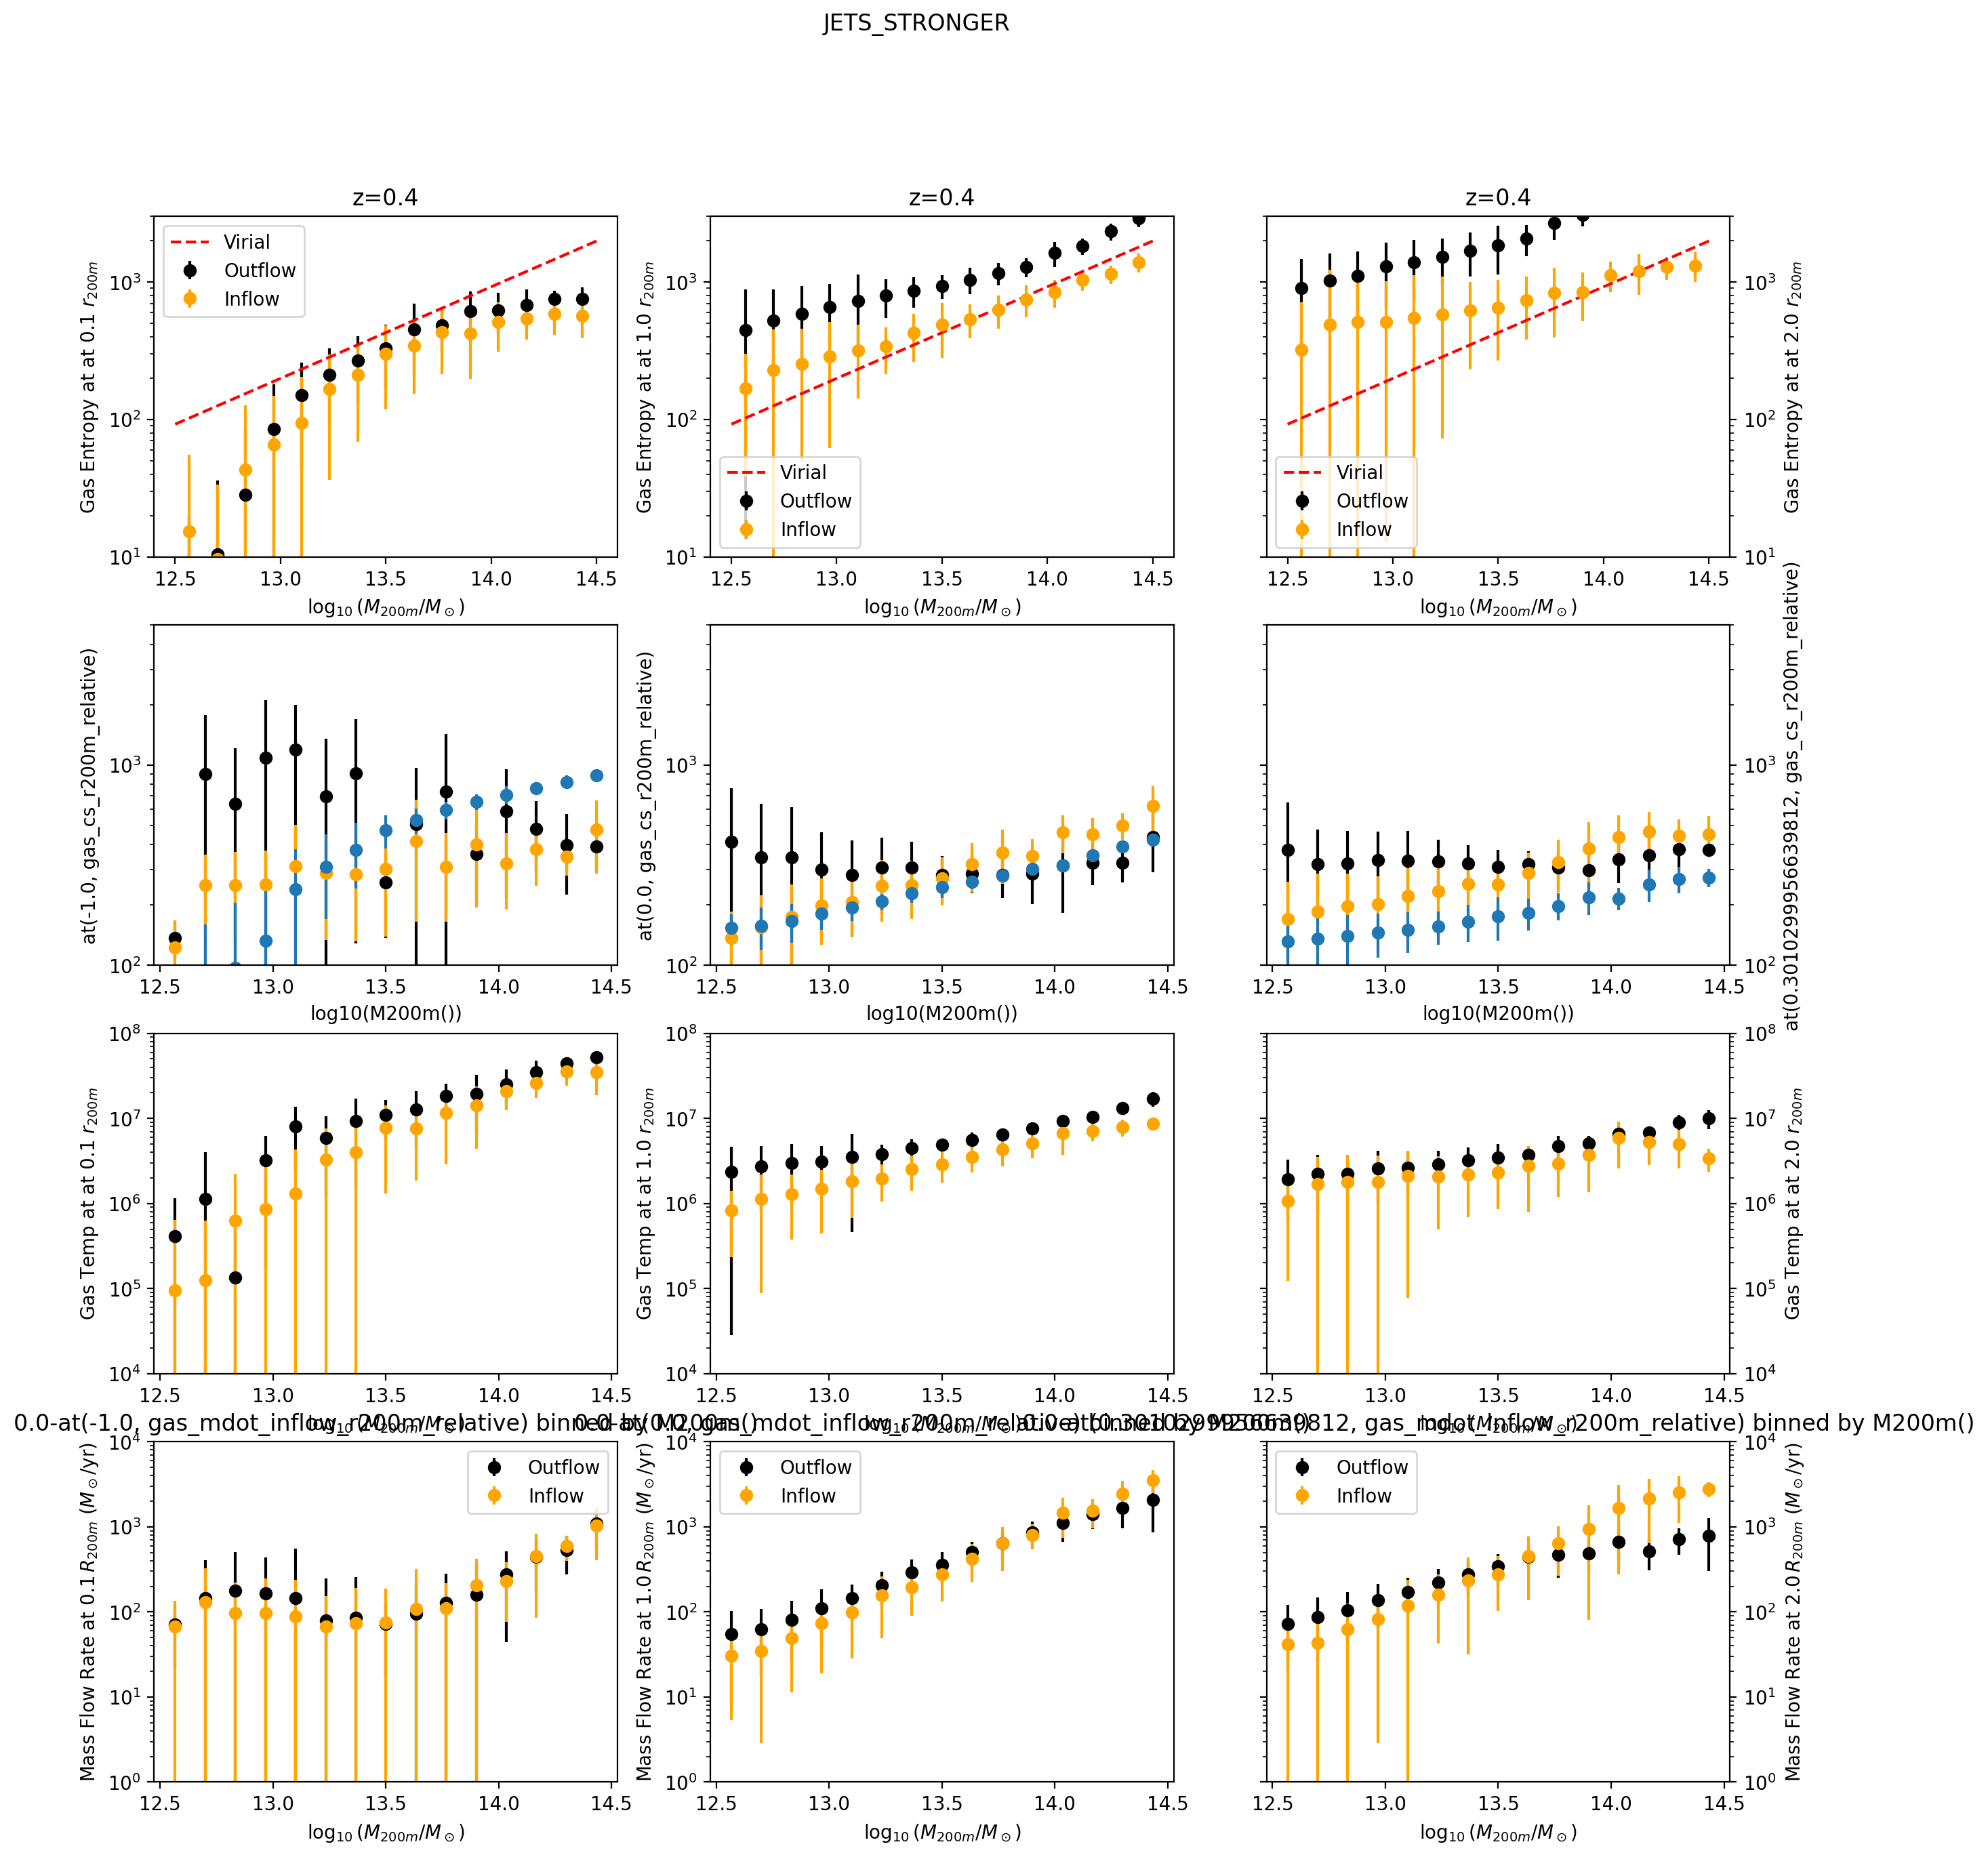

In [17]:
boxes = ["%STRONGEST_AGN%", "%FIDUCIAL", "%JETS", "%JETS_STRONGER%"]
for i, box in enumerate(boxes):
    make_outflow_diagnostic_plots(tsnum=4, boxname=box)
    p.suptitle(box.replace("%", ""))
    p.savefig(f"{i}_outflow_diagnostics_{box.replace('%','')}.pdf")